<a href="https://colab.research.google.com/github/yassni-s/Diplomado-en-ingenieria-ciencia-de-datos/blob/main/Copia_de_Capitulo2_SaberPro_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 CAPÍTULO 2. ANÁLISIS EXPLORATORIO DE DATOS — SABER PRO CAUCA
---
## Análisis Descriptivo de Brechas Socioeconómicas y Desempeño Académico
### Pruebas Saber Pro — Departamento del Cauca (2018–2022)

| Campo | Detalle |
|---|---|
| **Autoras** | Claudia Elizabeth Mejía Cuásquer · Yaseni Silva Bolaños |
| **Tutor** | Francisco Javier Ovando |
| **Institución** | Corporación Universitaria Comfacauca — Unicomfacauca |
| **Diplomado** | Ingeniería y Ciencia de Datos Aplicada (2026-1) |
| **Metodología** | CRISP-DM — Fase 3: Preparación de Datos + Fase 4: Análisis |
| **Motor** | Apache PySpark + matplotlib/seaborn |

---
### 📋 Estructura del Capítulo

| Sección | Contenido | OE |
|---|---|---|
| 2.1 | Limpieza y preparación de los datos | — |
| 2.2 | Identificación de datos faltantes, duplicados e inconsistencias | — |
| 2.3 | Distribución de los puntajes globales | OE1 |
| 2.4 | Análisis de resultados por competencias genéricas | OE1 |
| 2.5 | Comparación de tendencias entre 2018 y 2022 | OE1 |
| 2.6 | Relación entre puntajes y variables socioeconómicas | OE2 |
| 2.7 | Relación entre puntajes y variables familiares | OE2 |
| 2.8 | Relación entre puntajes y condiciones laborales | OE2 |
| 2.9 | Análisis de diferencias por tipo de institución y municipio | OE3 |
| 2.10 | Identificación y síntesis de brechas de desempeño académico | OE1, OE2, OE3 |

---
> ⚠️ **REQUISITO PREVIO:** Haber ejecutado el Capítulo 1 completamente.
> El archivo `cauca_limpio.parquet` debe existir en Google Drive → Mi unidad → SaberPro

---
## ⚙️ SETUP — Instalación, librerías y SparkSession

### Regla de oro en Google Colab
Cada vez que abra una sesión nueva debe ejecutar esta celda **antes que cualquier otra**.
Colab no guarda variables entre sesiones — solo guarda el código.

### ¿Por qué PySpark para el EDA?
El dataset del Cauca tiene aproximadamente **40.000–60.000 registros**.
Con pandas sería suficiente, pero usamos PySpark porque:
- Es la tecnología del Diplomado
- Las agrupaciones son más eficientes con grandes volúmenes
- Los resultados son escalables al dataset nacional (1.2M registros)
- Para las visualizaciones convertimos solo el **resultado** (pequeño) a pandas, no todo el dataset

In [1]:
# ─── INSTALACIÓN ─────────────────────────────────────────────────────────────
!pip install pyspark --quiet

import warnings
warnings.filterwarnings('ignore')

# ─── LIBRERÍAS PYSPARK ────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F       # mean, count, col, when, desc...
from pyspark.sql.types import *              # IntegerType, DoubleType...
from pyspark.sql.window import Window        # Funciones de ventana

# ─── LIBRERÍAS DE ANÁLISIS Y VISUALIZACIÓN ───────────────────────────────────
import pandas as pd                          # Solo para visualización de resultados
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

# ─── CONFIGURACIÓN VISUAL PROFESIONAL ────────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
sns.set_theme(style='whitegrid', palette='Blues_d')

# ─── SPARKSESSION ─────────────────────────────────────────────────────────────
spark = SparkSession.builder \
    .appName("SaberPro_EDA_Cauca_2018_2022") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("=" * 55)
print("  ✅ ENTORNO CONFIGURADO CORRECTAMENTE")
print("=" * 55)
print(f"  PySpark:  {spark.version}")
print(f"  pandas:   {pd.__version__}")
print(f"  App:      {spark.sparkContext.appName}")
print("=" * 55)

  ✅ ENTORNO CONFIGURADO CORRECTAMENTE
  PySpark:  4.0.2
  pandas:   2.2.2
  App:      SaberPro_EDA_Cauca_2018_2022


---
## 📁 Montar Google Drive y definir rutas del proyecto

In [2]:
# ─── MONTAR GOOGLE DRIVE ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ─── RUTAS DEL PROYECTO ───────────────────────────────────────────────────────
CARPETA          = '/content/drive/MyDrive/SaberPro'
RUTA_PARQUET     = f'{CARPETA}/cauca_limpio.parquet'
RUTA_DIVIPOLA    = f'{CARPETA}/divipola.csv'
RUTA_POWERBI     = f'{CARPETA}/cauca_powerbi.csv'
MEDIA_NACIONAL   = 150.0

# Variables de puntaje (usadas en todo el capítulo)
PUNTAJES         = ['PUNT_RAZONAMIENTO','PUNT_LECTURA',
                    'PUNT_ESCRITURA','PUNT_INGLES','PUNT_CIUDADANAS']
NOMBRES_PUNTAJES = ['Razonamiento','Lectura','Escritura','Inglés','Ciudadanas']

# ─── VERIFICAR ARCHIVOS ───────────────────────────────────────────────────────
print("=" * 55)
print("  📁 VERIFICACIÓN DE ARCHIVOS")
print("=" * 55)

for nombre, ruta in [("cauca_limpio.parquet", RUTA_PARQUET),
                     ("divipola.csv",         RUTA_DIVIPOLA)]:
    if os.path.exists(ruta):
        print(f"  ✅ {nombre}")
    else:
        print(f"  ❌ {nombre} — NO ENCONTRADO")
        print(f"     Ejecute primero el Capítulo 1")

print("=" * 55)

Mounted at /content/drive
  📁 VERIFICACIÓN DE ARCHIVOS
  ✅ cauca_limpio.parquet
  ✅ divipola.csv


---
## 2.1 Limpieza y preparación de los datos

### Objetivo de esta sección
Transformar el dataset procesado en el Capítulo 1 en un conjunto de datos limpio,
consistente y listo para el análisis exploratorio. Corresponde a la
**Fase 3 de CRISP-DM: Preparación de los Datos**.

### ¿Por qué leer Parquet en lugar del CSV original?
El archivo Parquet generado en el Capítulo 1 ya contiene:
- Solo los registros del Cauca (2018–2022)
- Solo las 15 variables del proyecto
- Tipos de datos correctos (integer, double, string)
- Es 5-10x más rápido de leer que el CSV completo

In [3]:
!pip install pyspark --quiet

import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_theme(style='whitegrid', palette='Blues_d')

spark = SparkSession.builder \
    .appName("SaberPro_EDA_Cauca") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ SparkSession lista — versión {spark.version}")

✅ SparkSession lista — versión 4.0.2


In [4]:
from google.colab import drive
drive.mount('/content/drive')

CARPETA        = '/content/drive/MyDrive/SaberPro'
RUTA_PARQUET   = f'{CARPETA}/cauca_limpio.parquet'
RUTA_DIVIPOLA  = f'{CARPETA}/divipola.csv'
RUTA_POWERBI   = f'{CARPETA}/cauca_powerbi.csv'
MEDIA_NACIONAL = 150.0

PUNTAJES         = ['PUNT_RAZONAMIENTO','PUNT_LECTURA',
                    'PUNT_ESCRITURA','PUNT_INGLES','PUNT_CIUDADANAS']
NOMBRES_PUNTAJES = ['Razonamiento','Lectura','Escritura','Inglés','Ciudadanas']

print(f"✅ Drive montado")
print(f"   Parquet: {'✅ existe' if os.path.exists(RUTA_PARQUET) else '❌ no encontrado'}")
print(f"   DIVIPOLA: {'✅ existe' if os.path.exists(RUTA_DIVIPOLA) else '❌ no encontrado'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive montado
   Parquet: ✅ existe
   DIVIPOLA: ✅ existe


In [5]:
# ─── PASO 1: Cargar el dataset desde Parquet ──────────────────────────────────
# Lee el resultado procesado del Capítulo 1
# Mucho más rápido que releer el CSV completo de 640 MB

print("⏳ Cargando dataset del Cauca desde Parquet...")
df_cauca = spark.read.parquet(RUTA_PARQUET)
df_cauca.cache()

total = df_cauca.count()
print(f"✅ Dataset cargado: {total:,} registros | {len(df_cauca.columns)} columnas")
df_cauca.show(5, truncate=40)

⏳ Cargando dataset del Cauca desde Parquet...
✅ Dataset cargado: 20,682 registros | 15 columnas
+-------+------------+-------------+------+---------+----------------------------------+----------------------------------+-------------------+-------------------------+------------------------+-----------------+------------+--------------+-----------+---------------+
|PERIODO|DEPARTAMENTO|COD_MUNICIPIO|GENERO|  ESTRATO|                        EDUC_PADRE|                        EDUC_MADRE|      HORAS_TRABAJO|             CARACTER_IES|              ORIGEN_IES|PUNT_RAZONAMIENTO|PUNT_LECTURA|PUNT_ESCRITURA|PUNT_INGLES|PUNT_CIUDADANAS|
+-------+------------+-------------+------+---------+----------------------------------+----------------------------------+-------------------+-------------------------+------------------------+-----------------+------------+--------------+-----------+---------------+
|  20203|       CAUCA|        19300|     F|Estrato 1|    Técnica o tecnológica completa|         

In [6]:
# ─── PASO 2: Eliminar registros duplicados exactos ───────────────────────────
# dropDuplicates() elimina filas que son 100% iguales en todas las columnas
# No elimina filas con diferencias mínimas — solo duplicados exactos

antes    = df_cauca.count()
df_cauca = df_cauca.dropDuplicates()
df_cauca.cache()
despues  = df_cauca.count()

print("=== LIMPIEZA DE DUPLICADOS ===")
print(f"  Registros antes:          {antes:,}")
print(f"  Registros después:        {despues:,}")
print(f"  Duplicados eliminados:    {antes - despues:,}")
print(f"  Estado: {'✅ Sin duplicados exactos' if antes == despues else '⚠️ Se eliminaron duplicados'}")

=== LIMPIEZA DE DUPLICADOS ===
  Registros antes:          20,682
  Registros después:        20,598
  Duplicados eliminados:    84
  Estado: ⚠️ Se eliminaron duplicados


In [7]:
# ─── PASO 3: Calcular puntaje global por estudiante ──────────────────────────
# El puntaje global = promedio simple de las 5 competencias genéricas
# Esta variable es el indicador principal de desempeño del proyecto

df_cauca = df_cauca.withColumn(
    'PUNT_GLOBAL',
    F.round(
        (F.col('PUNT_RAZONAMIENTO') + F.col('PUNT_LECTURA') +
         F.col('PUNT_ESCRITURA')   + F.col('PUNT_INGLES')  +
         F.col('PUNT_CIUDADANAS')) / 5.0,
        2
    )
)
df_cauca.cache()

# Estadísticas del puntaje global
stats = df_cauca.select('PUNT_GLOBAL').describe().toPandas()
print("=== PUNTAJE GLOBAL CALCULADO ===")
print(stats.to_string(index=False))
print(f"\n  Media de referencia nacional: {MEDIA_NACIONAL:.1f} puntos")

=== PUNTAJE GLOBAL CALCULADO ===
summary        PUNT_GLOBAL
  count              20363
   mean  139.8971467858371
 stddev 23.640877490258124
    min               13.8
    max              233.0

  Media de referencia nacional: 150.0 puntos


In [8]:
# ─── PASO 4: Verificación final del dataset limpio ───────────────────────────
print("=" * 55)
print("  ✅ DATASET LIMPIO Y LISTO PARA EL ANÁLISIS")
print("=" * 55)
print(f"  Registros totales:     {df_cauca.count():,}")
print(f"  Columnas:              {len(df_cauca.columns)}")
print(f"  Columnas disponibles:")
for col in df_cauca.columns:
    print(f"    • {col}")
print("=" * 55)

  ✅ DATASET LIMPIO Y LISTO PARA EL ANÁLISIS
  Registros totales:     20,598
  Columnas:              16
  Columnas disponibles:
    • PERIODO
    • DEPARTAMENTO
    • COD_MUNICIPIO
    • GENERO
    • ESTRATO
    • EDUC_PADRE
    • EDUC_MADRE
    • HORAS_TRABAJO
    • CARACTER_IES
    • ORIGEN_IES
    • PUNT_RAZONAMIENTO
    • PUNT_LECTURA
    • PUNT_ESCRITURA
    • PUNT_INGLES
    • PUNT_CIUDADANAS
    • PUNT_GLOBAL


---
## 2.2 Identificación de datos faltantes, duplicados e inconsistencias

### Objetivo
Documentar el estado de calidad del dataset del Cauca antes del análisis.
Esta revisión permite tomar decisiones informadas sobre el tratamiento de
valores faltantes durante el EDA.

### Decisión sobre los nulos
En este proyecto **no eliminamos filas con nulos** en variables categóricas
(estrato, educación de los padres, horas de trabajo). Estos nulos son informativos:
representan estudiantes que no declararon esa información al inscribirse al examen.
En cada análisis los excluimos localmente con `.dropna()` o `.filter()`.

In [9]:
# ─── Valores nulos por variable ───────────────────────────────────────────────
# Contamos tanto valores null como cadenas vacías ('')
# ambos representan información faltante

print("=== VALORES NULOS Y FALTANTES POR VARIABLE ===")

total_reg  = df_cauca.count()
nulos_expr = [
    F.count(F.when(
        F.col(c).isNull() | (F.col(c).cast('string') == ''), c
    )).alias(c)
    for c in df_cauca.columns
]

nulos_row = df_cauca.select(nulos_expr).collect()[0]

nulos_pd = pd.DataFrame({
    'Variable':       df_cauca.columns,
    'Nulos':          [nulos_row[c] for c in df_cauca.columns],
})
nulos_pd['Porcentaje (%)'] = (nulos_pd['Nulos'] / total_reg * 100).round(2)
nulos_pd['Decisión'] = nulos_pd['Porcentaje (%)'].apply(
    lambda x: '✅ Sin acción' if x == 0
    else ('⚠️ Excluir en análisis parciales' if x < 30
    else '❌ Alta tasa — documentar')
)
nulos_pd = nulos_pd.sort_values('Porcentaje (%)', ascending=False)
print(nulos_pd.to_string(index=False))

=== VALORES NULOS Y FALTANTES POR VARIABLE ===
         Variable  Nulos  Porcentaje (%)                         Decisión
          ESTRATO   1281            6.22 ⚠️ Excluir en análisis parciales
    HORAS_TRABAJO   1188            5.77 ⚠️ Excluir en análisis parciales
       EDUC_MADRE    981            4.76 ⚠️ Excluir en análisis parciales
       EDUC_PADRE    940            4.56 ⚠️ Excluir en análisis parciales
      PUNT_GLOBAL    235            1.14 ⚠️ Excluir en análisis parciales
   PUNT_ESCRITURA    232            1.13 ⚠️ Excluir en análisis parciales
      PUNT_INGLES      3            0.01 ⚠️ Excluir en análisis parciales
           GENERO      0            0.00                     ✅ Sin acción
          PERIODO      0            0.00                     ✅ Sin acción
     DEPARTAMENTO      0            0.00                     ✅ Sin acción
    COD_MUNICIPIO      0            0.00                     ✅ Sin acción
     CARACTER_IES      0            0.00                     ✅ Si

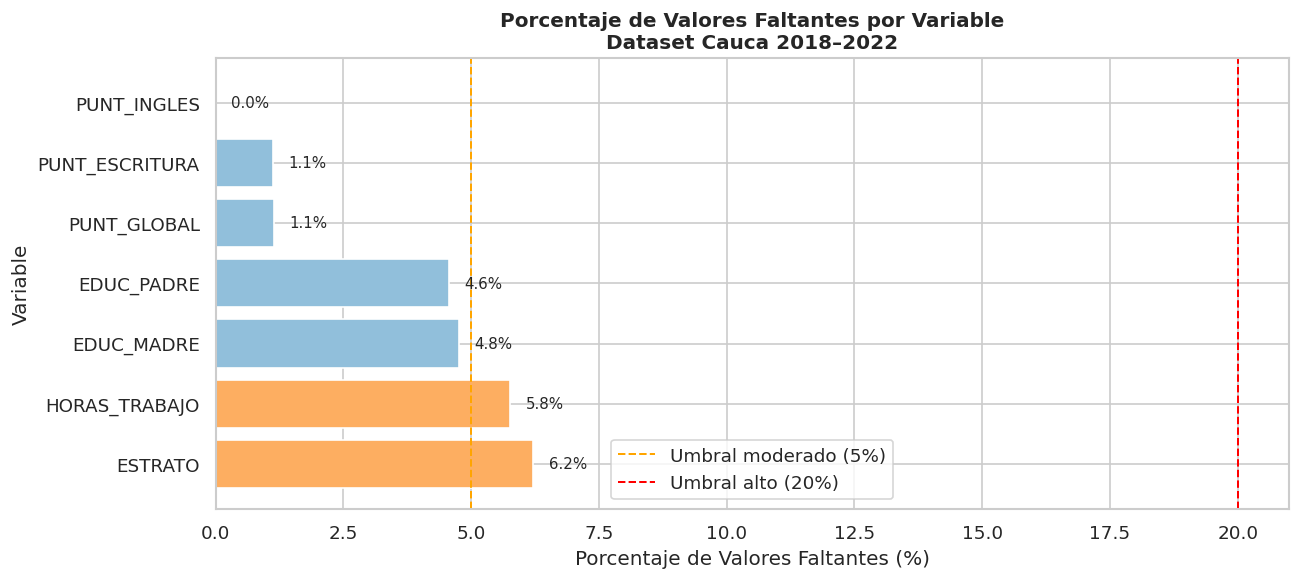

In [10]:
# ─── Visualización de nulos ───────────────────────────────────────────────────
nulos_viz = nulos_pd[nulos_pd['Nulos'] > 0].copy()

if len(nulos_viz) > 0:
    plt.figure(figsize=(11, 5))
    colores = ['#d73027' if p > 20 else '#fdae61' if p > 5 else '#91bfdb'
               for p in nulos_viz['Porcentaje (%)']]
    bars = plt.barh(nulos_viz['Variable'], nulos_viz['Porcentaje (%)'],
                    color=colores, edgecolor='white')
    plt.axvline(x=5,  color='orange', linestyle='--', linewidth=1.2,
                label='Umbral moderado (5%)')
    plt.axvline(x=20, color='red',    linestyle='--', linewidth=1.2,
                label='Umbral alto (20%)')

    # Anotar porcentajes
    for bar, pct in zip(bars, nulos_viz['Porcentaje (%)']):
        plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=9)

    plt.title('Porcentaje de Valores Faltantes por Variable\n'
              'Dataset Cauca 2018–2022')
    plt.xlabel('Porcentaje de Valores Faltantes (%)')
    plt.ylabel('Variable')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay variables con valores faltantes")

In [11]:
# ─── Inconsistencias en variables categóricas ────────────────────────────────
# Revisamos los valores únicos para detectar inconsistencias
# Ej: 'OFICIAL' vs 'oficial' serían dos categorías distintas (error)

print("=== VALORES ÚNICOS EN VARIABLES CATEGÓRICAS ===")
categoricas = ['ESTRATO','HORAS_TRABAJO','ORIGEN_IES','CARACTER_IES','GENERO']

for col in categoricas:
    print(f"\n{'─'*55}")
    print(f"  {col}:")
    df_cauca.groupBy(col).count() \
        .orderBy(F.desc('count')) \
        .show(10, truncate=False)

=== VALORES ÚNICOS EN VARIABLES CATEGÓRICAS ===

───────────────────────────────────────────────────────
  ESTRATO:
+-----------+-----+
|ESTRATO    |count|
+-----------+-----+
|Estrato 1  |7218 |
|Estrato 2  |6419 |
|Estrato 3  |3823 |
|NULL       |1281 |
|Estrato 4  |1211 |
|Estrato 5  |307  |
|Sin Estrato|257  |
|Estrato 6  |82   |
+-----------+-----+


───────────────────────────────────────────────────────
  HORAS_TRABAJO:
+-------------------+-----+
|HORAS_TRABAJO      |count|
+-------------------+-----+
|Más de 30 horas    |5039 |
|Entre 11 y 20 horas|4412 |
|Menos de 10 horas  |3703 |
|0                  |3363 |
|Entre 21 y 30 horas|2893 |
|NULL               |1188 |
+-------------------+-----+


───────────────────────────────────────────────────────
  ORIGEN_IES:
+------------------------+-----+
|ORIGEN_IES              |count|
+------------------------+-----+
|OFICIAL NACIONAL        |8206 |
|NO OFICIAL - FUNDACIÓN  |5697 |
|NO OFICIAL - CORPORACIÓN|5237 |
|OFICIAL DEPARTAMEN

In [12]:
# ─── Estadísticas básicas de puntajes ────────────────────────────────────────
# Permite detectar valores fuera del rango válido (0-300)
# min muy bajo o max muy alto indicaría errores de medición

print("=== ESTADÍSTICAS BÁSICAS DE PUNTAJES — CAUCA ===")
df_cauca.select(PUNTAJES + ['PUNT_GLOBAL']).describe().show(truncate=False)

print("\nRango de puntajes esperado:")
print("  Mínimo válido:   0 puntos")
print("  Máximo válido:   300 puntos")
print("  Media nacional:  150 puntos")
print("  Desv. estándar:  ~30 puntos")

=== ESTADÍSTICAS BÁSICAS DE PUNTAJES — CAUCA ===
+-------+-----------------+------------------+------------------+------------------+-----------------+------------------+
|summary|PUNT_RAZONAMIENTO|PUNT_LECTURA      |PUNT_ESCRITURA    |PUNT_INGLES       |PUNT_CIUDADANAS  |PUNT_GLOBAL       |
+-------+-----------------+------------------+------------------+------------------+-----------------+------------------+
|count  |20598            |20598             |20366             |20595             |20598            |20363             |
|mean   |139.9047480337897|142.56510340809788|137.44112736914465|140.44365137169217|138.6072919700942|139.8971467858371 |
|stddev |31.52429981212229|30.193673524072395|42.15297624044597 |30.132860569060334|32.46509427374486|23.640877490258124|
|min    |0.0              |0.0               |0.0               |0.0               |0.0              |13.8              |
|max    |300.0            |300.0             |300.0             |300.0             |300.0        

---
## 2.3 Distribución de los puntajes globales

### Objetivo (OE1)
Caracterizar cómo se distribuye el desempeño global de los estudiantes
universitarios del Cauca y cuál es la brecha frente a la media nacional de referencia (150 puntos).

### ¿Qué es el puntaje global?
Es el promedio simple de las 5 competencias genéricas por estudiante.
Permite una visión integrada del desempeño sin profundizar aún en competencias específicas.

In [13]:
# ─── Estadísticas descriptivas del puntaje global ────────────────────────────
stats_global = df_cauca.select('PUNT_GLOBAL').dropna().describe().toPandas()
media_cauca  = df_cauca.select(F.mean('PUNT_GLOBAL')).collect()[0][0]

print("=== ESTADÍSTICAS DEL PUNTAJE GLOBAL — CAUCA 2018–2022 ===")
print(stats_global.to_string(index=False))
print(f"\n  Media Cauca:             {media_cauca:.2f} puntos")
print(f"  Media Nacional:          {MEDIA_NACIONAL:.2f} puntos")
print(f"  Brecha Cauca vs Nacional:{MEDIA_NACIONAL - media_cauca:.2f} puntos")
print(f"  Dirección:               {'⬇️ Por debajo' if media_cauca < MEDIA_NACIONAL else '⬆️ Por encima'} de la media nacional")

=== ESTADÍSTICAS DEL PUNTAJE GLOBAL — CAUCA 2018–2022 ===
summary        PUNT_GLOBAL
  count              20363
   mean  139.8971467858371
 stddev 23.640877490258124
    min               13.8
    max              233.0

  Media Cauca:             139.90 puntos
  Media Nacional:          150.00 puntos
  Brecha Cauca vs Nacional:10.10 puntos
  Dirección:               ⬇️ Por debajo de la media nacional


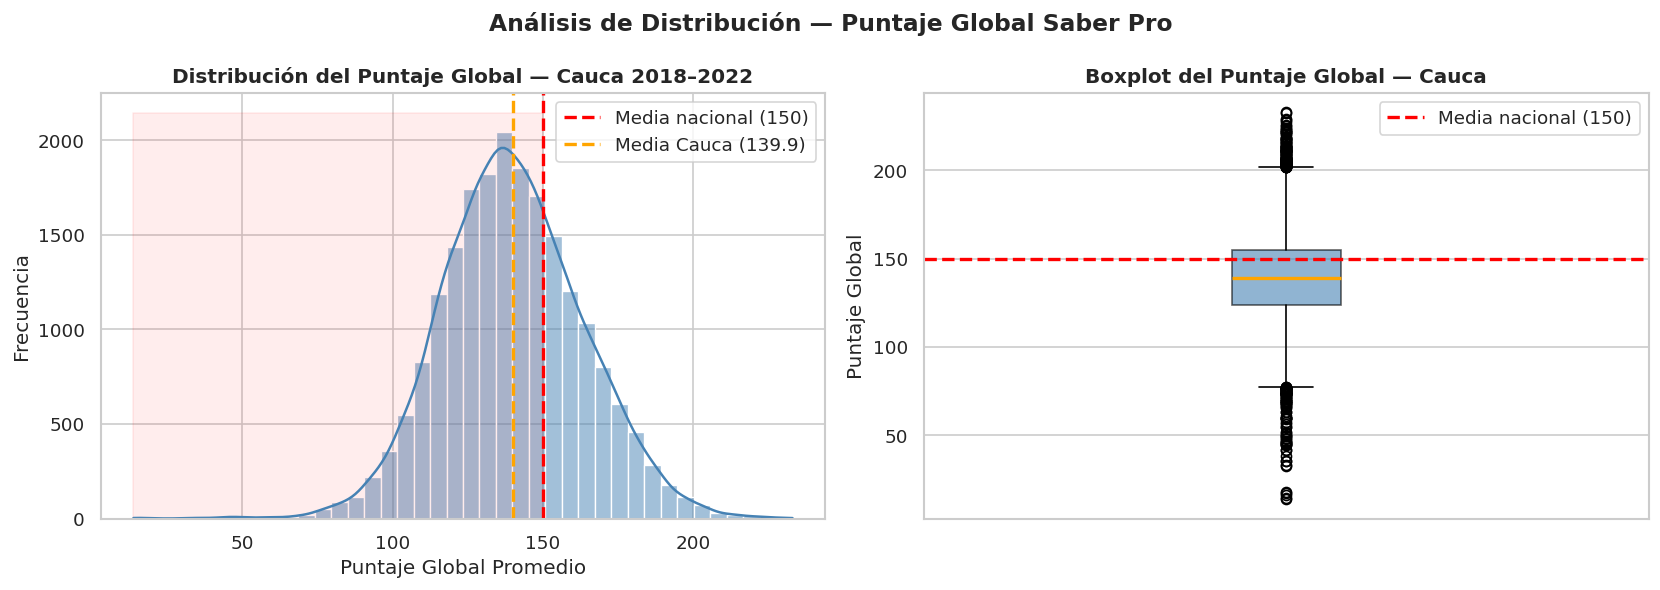

In [14]:
# ─── Histograma del puntaje global ───────────────────────────────────────────
# Convertimos SOLO la columna PUNT_GLOBAL a pandas (no todo el dataset)
# Esto es la práctica correcta con PySpark: agregar en Spark, visualizar en pandas

punt_pd = df_cauca.select('PUNT_GLOBAL').dropna().toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE
sns.histplot(punt_pd['PUNT_GLOBAL'], bins=40, kde=True,
             color='steelblue', edgecolor='white', ax=axes[0])
axes[0].axvline(x=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
axes[0].axvline(x=media_cauca, color='orange', linestyle='--', linewidth=2,
                label=f'Media Cauca ({media_cauca:.1f})')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1] if axes[0].get_ylim()[1]>0 else 5000],
                       punt_pd['PUNT_GLOBAL'].min(), MEDIA_NACIONAL,
                       alpha=0.07, color='red')
axes[0].set_title('Distribución del Puntaje Global — Cauca 2018–2022')
axes[0].set_xlabel('Puntaje Global Promedio')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(punt_pd['PUNT_GLOBAL'].dropna(),
                     patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='orange', linewidth=2))
axes[1].axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
axes[1].set_title('Boxplot del Puntaje Global — Cauca')
axes[1].set_ylabel('Puntaje Global')
axes[1].set_xticks([])
axes[1].legend()

plt.suptitle('Análisis de Distribución — Puntaje Global Saber Pro',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
del punt_pd

=== PUNTAJE GLOBAL PROMEDIO POR PERÍODO ===
 PERIODO  Promedio  Estudiantes
   20183    141.91         4781
   20184    115.00            1
   20194    159.17           13
   20195    140.29         5326
   20196    131.73            3
   20202    119.20            1
   20203    140.69         4409
   20212    137.30         4195
   20213    163.62           10
   20222    136.98         1624


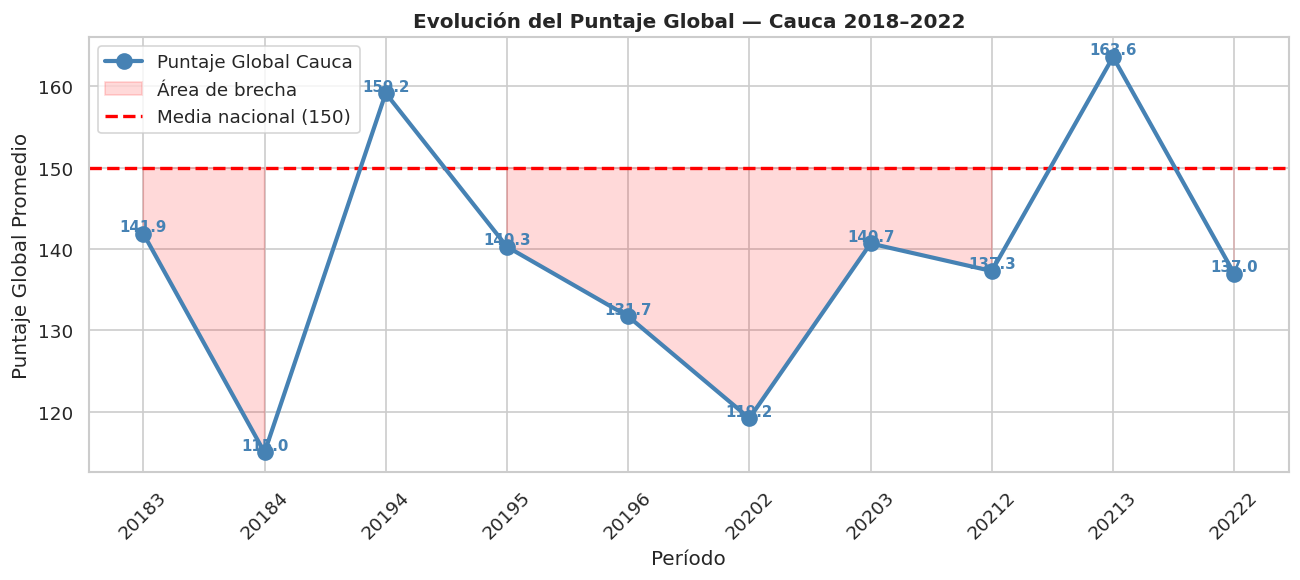

In [15]:
# ─── Puntaje global promedio por período ─────────────────────────────────────
tendencia_global = df_cauca.groupBy('PERIODO') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio'),
         F.count('PUNT_GLOBAL').alias('Estudiantes')) \
    .orderBy('PERIODO') \
    .toPandas()

print("=== PUNTAJE GLOBAL PROMEDIO POR PERÍODO ===")
print(tendencia_global.to_string(index=False))

# Gráfico de línea con área de brecha
plt.figure(figsize=(11, 5))
plt.plot(tendencia_global['PERIODO'].astype(str),
         tendencia_global['Promedio'],
         marker='o', color='steelblue', linewidth=2.5, markersize=9,
         label='Puntaje Global Cauca', zorder=3)

plt.fill_between(range(len(tendencia_global)),
                 tendencia_global['Promedio'], MEDIA_NACIONAL,
                 where=(tendencia_global['Promedio'] < MEDIA_NACIONAL),
                 alpha=0.15, color='red', label='Área de brecha')

plt.axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
            label=f'Media nacional ({MEDIA_NACIONAL:.0f})', zorder=2)

# Anotar valores sobre cada punto
for i, row in tendencia_global.iterrows():
    plt.annotate(f"{row['Promedio']:.1f}",
                 xy=(i, row['Promedio'] + 0.3),
                 ha='center', fontsize=9, color='steelblue', fontweight='bold')

plt.title('Evolución del Puntaje Global — Cauca 2018–2022')
plt.xlabel('Período')
plt.ylabel('Puntaje Global Promedio')
plt.xticks(range(len(tendencia_global)),
           tendencia_global['PERIODO'].astype(str), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ─── Comparación Cauca vs Media Nacional ─────────────────────────────────────
print("=== COMPARACIÓN CAUCA VS MEDIA NACIONAL ===")
print(f"  Media Cauca 2018–2022:     {media_cauca:.2f} puntos")
print(f"  Media Nacional referencia: {MEDIA_NACIONAL:.2f} puntos")
print(f"  Brecha:                    {MEDIA_NACIONAL - media_cauca:.2f} puntos")
print(f"  % de la media nacional:    {(media_cauca/MEDIA_NACIONAL*100):.1f}%")
print(f"\n  Período con puntaje más bajo: "
      f"{tendencia_global.loc[tendencia_global['Promedio'].idxmin(),'PERIODO']}"
      f" ({tendencia_global['Promedio'].min():.2f} pts)")
print(f"  Período con puntaje más alto: "
      f"{tendencia_global.loc[tendencia_global['Promedio'].idxmax(),'PERIODO']}"
      f" ({tendencia_global['Promedio'].max():.2f} pts)")

=== COMPARACIÓN CAUCA VS MEDIA NACIONAL ===
  Media Cauca 2018–2022:     139.90 puntos
  Media Nacional referencia: 150.00 puntos
  Brecha:                    10.10 puntos
  % de la media nacional:    93.3%

  Período con puntaje más bajo: 20184 (115.00 pts)
  Período con puntaje más alto: 20213 (163.62 pts)


---
## 2.4 Análisis de resultados por competencias genéricas

### Objetivo (OE1)
Evaluar el desempeño por cada una de las 5 competencias genéricas
e identificar cuáles presentan mayor rezago frente a la media nacional.

### Las 5 competencias evaluadas
1. **Razonamiento Cuantitativo** → uso de matemáticas en contextos reales
2. **Lectura Crítica** → comprensión e interpretación de textos
3. **Comunicación Escrita** → producción de textos coherentes
4. **Inglés** → comprensión lectora en lengua extranjera
5. **Competencias Ciudadanas** → pensamiento crítico y convivencia

In [17]:
# ─── Promedio por competencia vs media nacional ───────────────────────────────
promedios_row = df_cauca.select(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)]
).collect()[0]

resumen_comp = pd.DataFrame({
    'Competencia':    NOMBRES_PUNTAJES,
    'Promedio Cauca': [promedios_row[n] for n in NOMBRES_PUNTAJES],
    'Media Nacional': MEDIA_NACIONAL
})
resumen_comp['Brecha']    = (MEDIA_NACIONAL - resumen_comp['Promedio Cauca']).round(2)
resumen_comp['% Brecha']  = (resumen_comp['Brecha'] / MEDIA_NACIONAL * 100).round(2)
resumen_comp['Estado']    = resumen_comp['Brecha'].apply(
    lambda x: '🔴 Alta brecha' if x > 5 else ('🟡 Brecha moderada' if x > 0 else '🟢 Sobre la media')
)
resumen_comp = resumen_comp.sort_values('Brecha', ascending=False)

print("=== PROMEDIO POR COMPETENCIA VS MEDIA NACIONAL ===")
print(resumen_comp.to_string(index=False))

=== PROMEDIO POR COMPETENCIA VS MEDIA NACIONAL ===
 Competencia  Promedio Cauca  Media Nacional  Brecha  % Brecha        Estado
   Escritura          137.44           150.0   12.56      8.37 🔴 Alta brecha
  Ciudadanas          138.61           150.0   11.39      7.59 🔴 Alta brecha
Razonamiento          139.90           150.0   10.10      6.73 🔴 Alta brecha
      Inglés          140.44           150.0    9.56      6.37 🔴 Alta brecha
     Lectura          142.57           150.0    7.43      4.95 🔴 Alta brecha


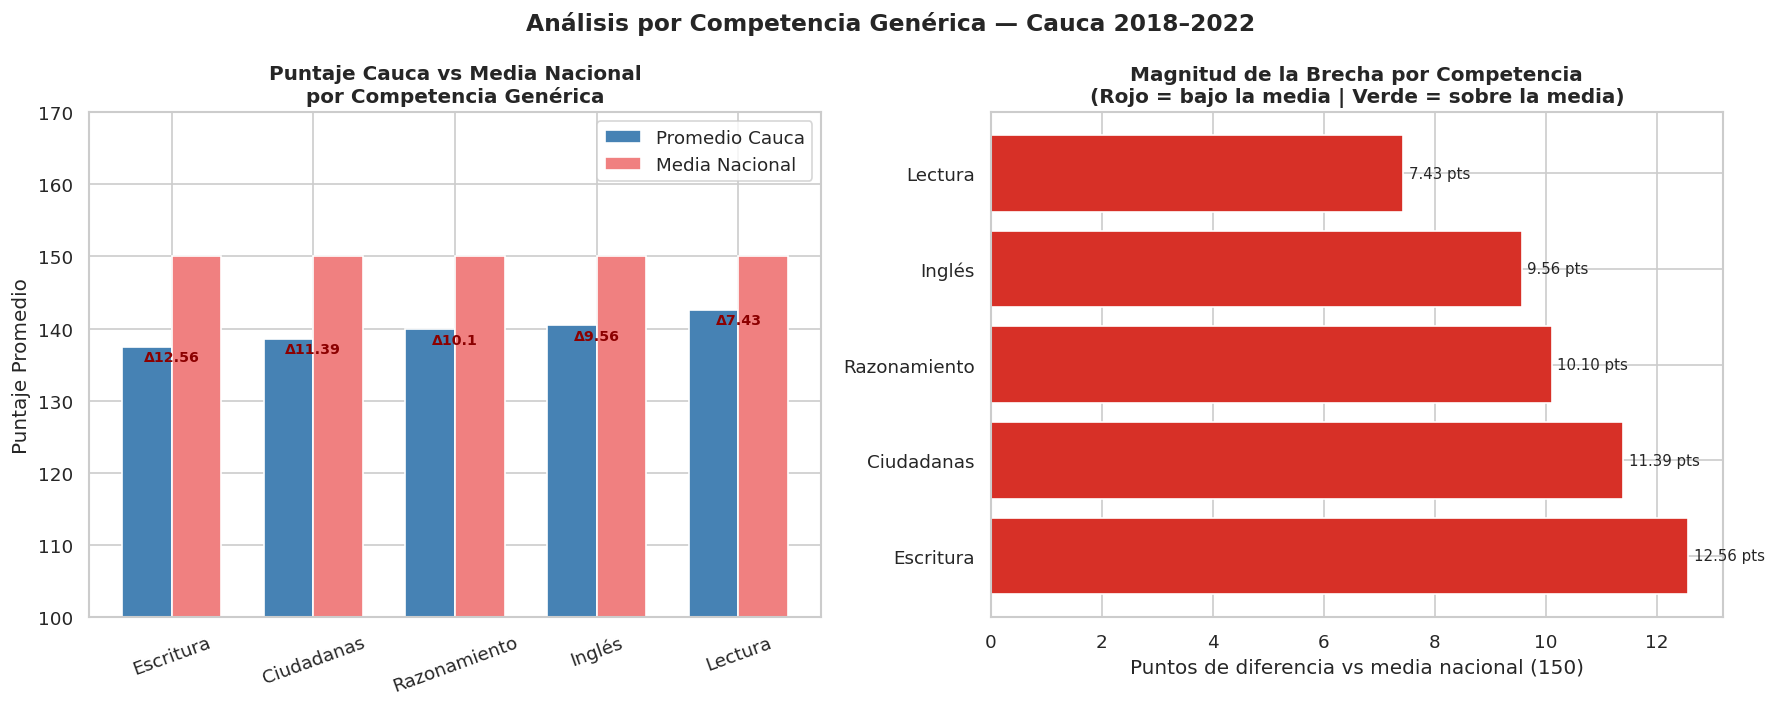

In [18]:
# ─── Gráfico comparativo: Cauca vs Nacional por competencia ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barras dobles: Cauca vs Nacional
x_pos = range(len(resumen_comp))
ancho = 0.35

axes[0].bar([p - ancho/2 for p in x_pos],
            resumen_comp['Promedio Cauca'],
            width=ancho, label='Promedio Cauca',
            color='steelblue', edgecolor='white')
axes[0].bar([p + ancho/2 for p in x_pos],
            resumen_comp['Media Nacional'],
            width=ancho, label='Media Nacional',
            color='lightcoral', edgecolor='white')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(resumen_comp['Competencia'], rotation=20)
axes[0].set_ylim(100, 170)
axes[0].set_title('Puntaje Cauca vs Media Nacional\npor Competencia Genérica')
axes[0].set_ylabel('Puntaje Promedio')
axes[0].legend()

# Anotar brechas
for i, row in resumen_comp.reset_index(drop=True).iterrows():
    axes[0].annotate(f"Δ{row['Brecha']}",
                     xy=(i, min(row['Promedio Cauca'], MEDIA_NACIONAL) - 2),
                     ha='center', fontsize=8.5, color='darkred', fontweight='bold')

# Brecha horizontal
colores_b = ['#d73027' if b > 0 else '#1a9850' for b in resumen_comp['Brecha']]
bars = axes[1].barh(resumen_comp['Competencia'], resumen_comp['Brecha'],
                    color=colores_b, edgecolor='white')
axes[1].axvline(x=0, color='black', linewidth=1.2)
axes[1].set_title('Magnitud de la Brecha por Competencia\n'
                  '(Rojo = bajo la media | Verde = sobre la media)')
axes[1].set_xlabel('Puntos de diferencia vs media nacional (150)')

for bar, val in zip(bars, resumen_comp['Brecha']):
    axes[1].text(val + 0.1 if val >= 0 else val - 0.1,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.2f} pts', va='center', fontsize=9,
                 ha='left' if val >= 0 else 'right')

plt.suptitle('Análisis por Competencia Genérica — Cauca 2018–2022',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

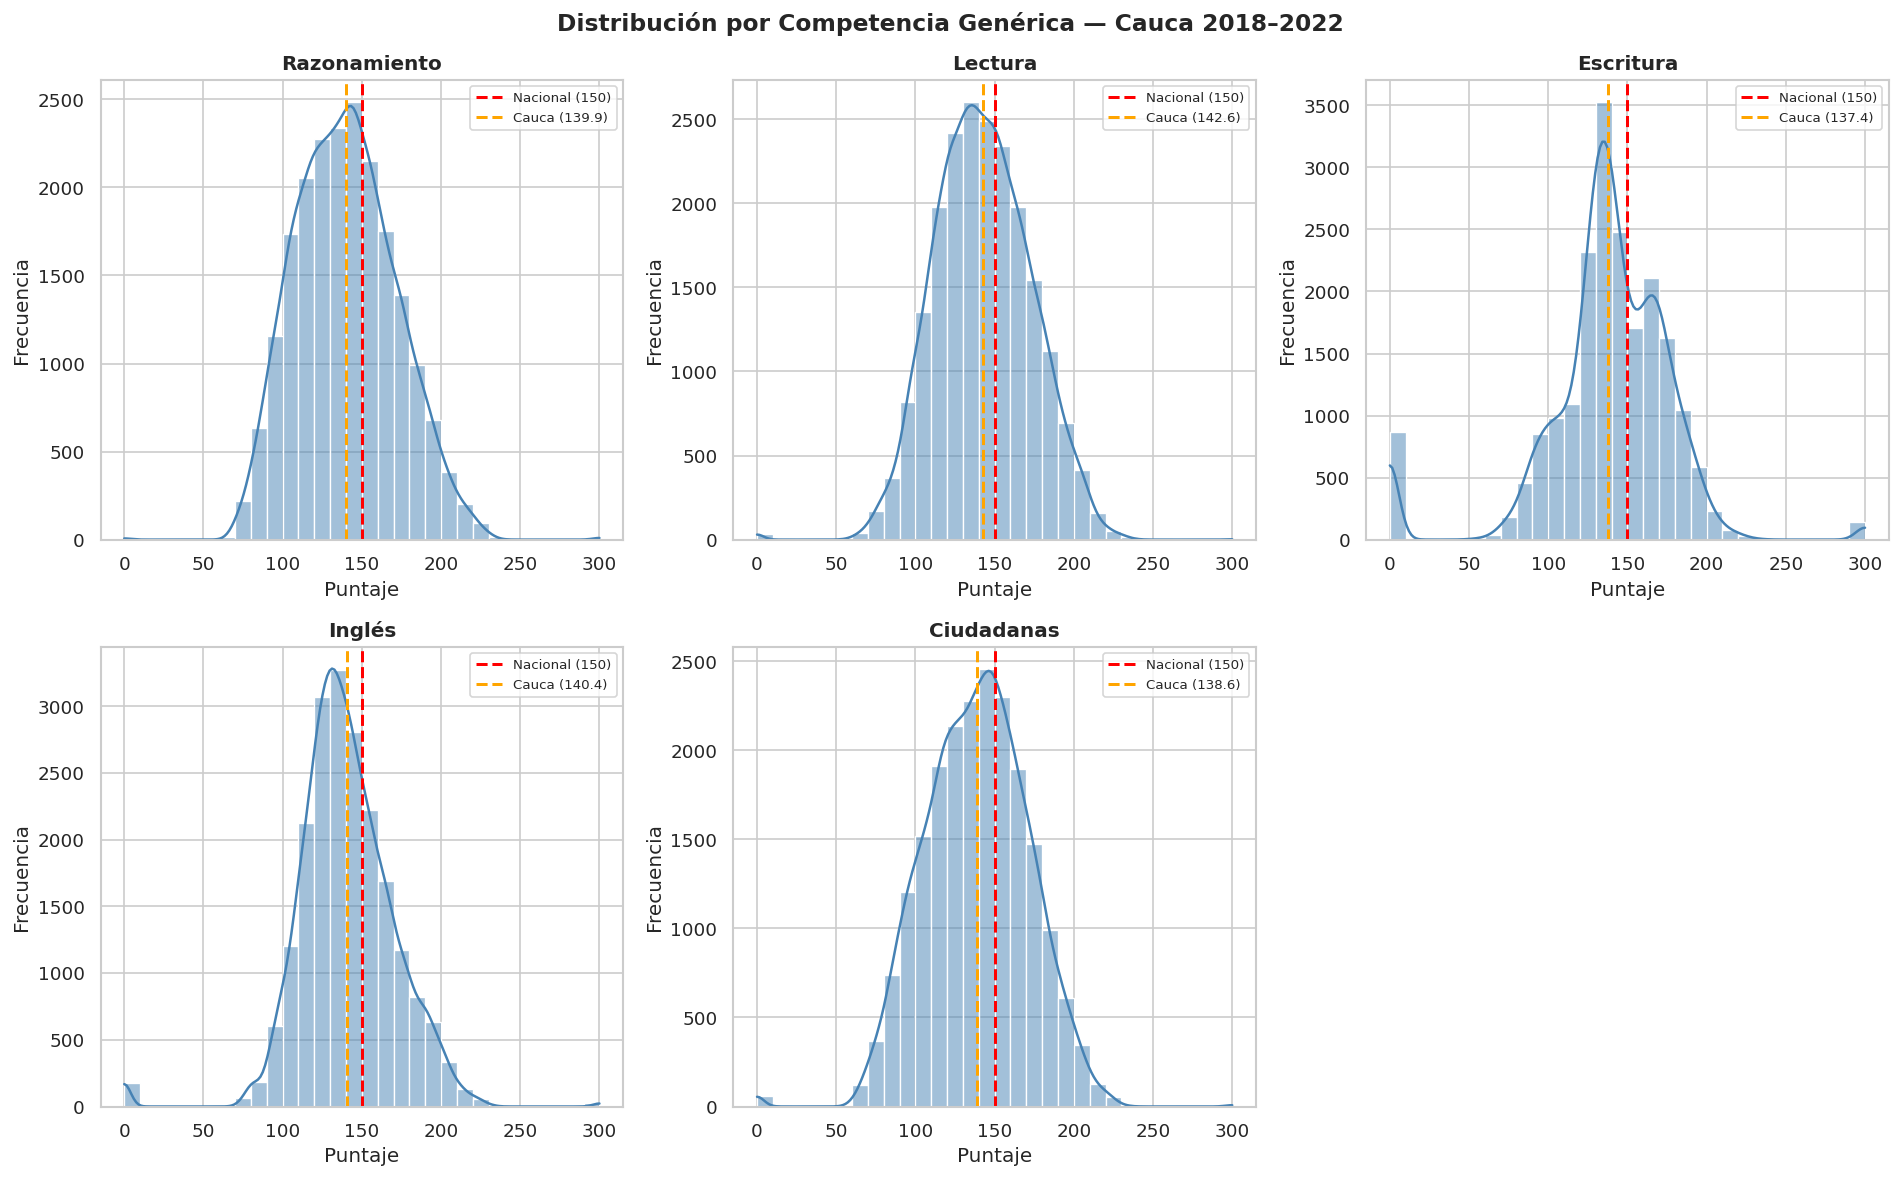

In [19]:
# ─── Histograma individual por cada competencia ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (col, nombre) in enumerate(zip(PUNTAJES, NOMBRES_PUNTAJES)):
    # Convertir solo esta columna a pandas
    datos = df_cauca.select(col).dropna().toPandas()
    media_comp = datos[col].mean()

    sns.histplot(datos[col], bins=30, kde=True, color='steelblue',
                 edgecolor='white', ax=axes[i])
    axes[i].axvline(x=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=1.8,
                    label=f'Nacional ({MEDIA_NACIONAL:.0f})')
    axes[i].axvline(x=media_comp, color='orange', linestyle='--', linewidth=1.8,
                    label=f'Cauca ({media_comp:.1f})')
    axes[i].set_title(nombre, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Puntaje')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)
    del datos

axes[5].set_visible(False)

plt.suptitle('Distribución por Competencia Genérica — Cauca 2018–2022',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

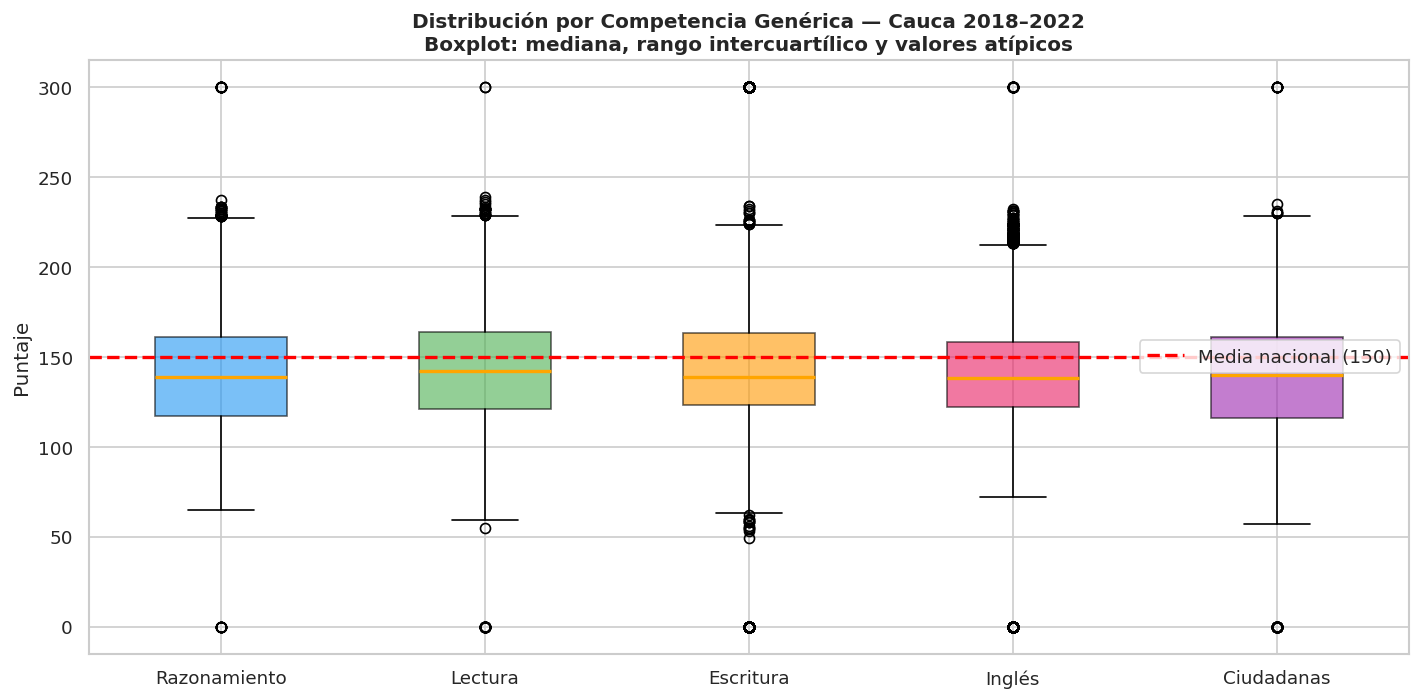

In [20]:
# ─── Boxplot comparativo por competencia ─────────────────────────────────────
# Permite ver dispersión, mediana y valores atípicos por competencia

comp_pd = df_cauca.select(PUNTAJES).dropna().toPandas()
comp_pd.columns = NOMBRES_PUNTAJES

plt.figure(figsize=(12, 6))
bp = plt.boxplot([comp_pd[n].dropna() for n in NOMBRES_PUNTAJES],
                 labels=NOMBRES_PUNTAJES,
                 patch_artist=True,
                 medianprops=dict(color='orange', linewidth=2))

colores_box = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
            label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
plt.title('Distribución por Competencia Genérica — Cauca 2018–2022\n'
          'Boxplot: mediana, rango intercuartílico y valores atípicos')
plt.ylabel('Puntaje')
plt.legend()
plt.tight_layout()
plt.show()
del comp_pd

---
## 2.5 Comparación de tendencias entre 2018 y 2022

### Objetivo (OE1)
Identificar la evolución longitudinal del desempeño por competencia,
detectar años críticos (especialmente en el periodo 2020-2021)
y determinar si las brechas se ampliaron o redujeron en el período estudiado.


In [21]:
# ─── Promedio por competencia y período ──────────────────────────────────────
tendencia = df_cauca.groupBy('PERIODO').agg(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)],
    F.round(F.mean('PUNT_GLOBAL'), 2).alias('Global')
).orderBy('PERIODO').toPandas()

print("=== PROMEDIO POR COMPETENCIA Y PERÍODO ===")
print(tendencia.to_string(index=False))

=== PROMEDIO POR COMPETENCIA Y PERÍODO ===
 PERIODO  Razonamiento  Lectura  Escritura  Inglés  Ciudadanas  Global
   20183        142.03   142.97     148.34  138.53      135.57  141.91
   20184        101.00   111.00     100.00  124.00      139.00  115.00
   20194        152.92   147.69     148.85  173.92      172.46  159.17
   20195        140.73   143.19     142.01  139.12      136.42  140.29
   20196        133.67   120.00     128.67  130.67      145.67  131.73
   20202        114.00   117.00     100.00  133.00      132.00  119.20
   20203        139.26   143.78     131.55  142.82      146.02  140.69
   20212        136.63   138.59     134.01  141.14      136.13  137.30
   20213        163.00   162.90     145.60  179.70      166.90  163.62
   20222        140.66   146.13     115.15  141.97      140.98  136.98


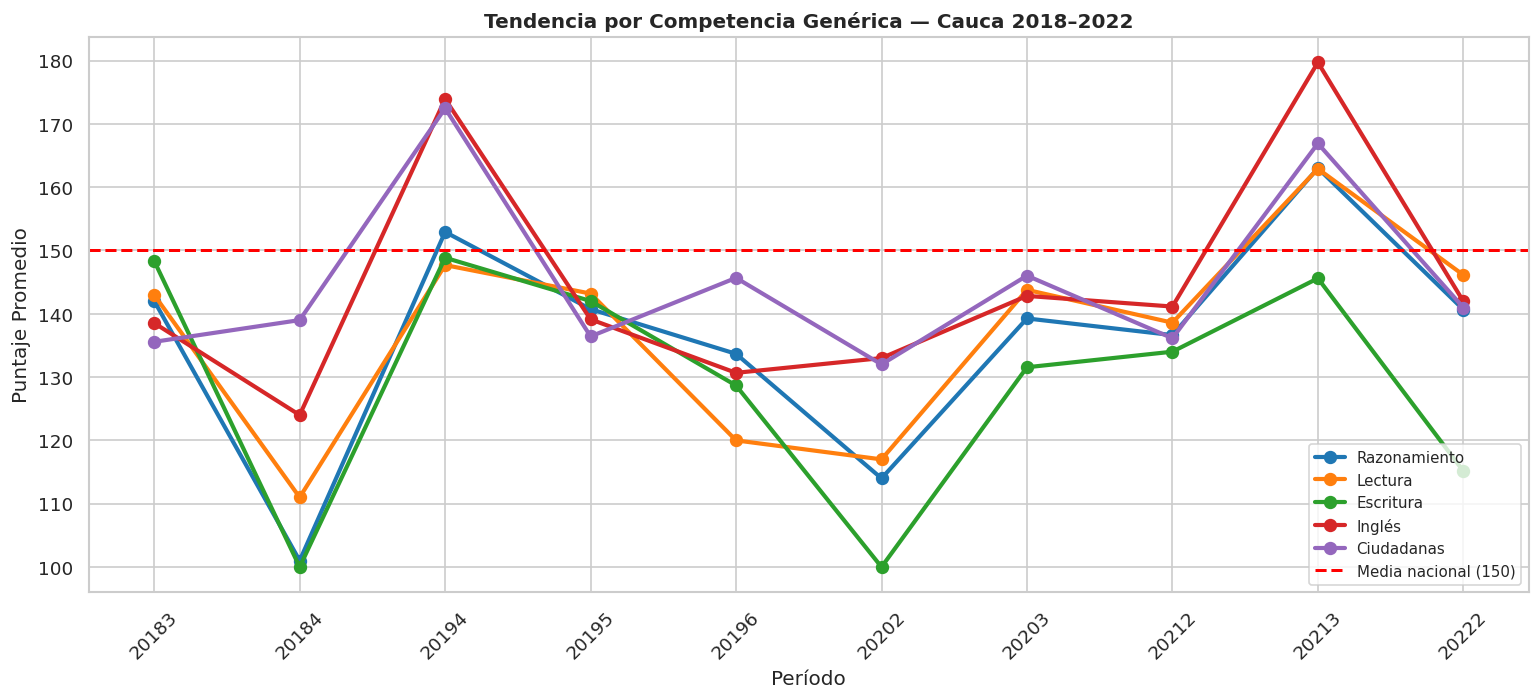

In [22]:
# ─── Líneas de tendencia por competencia ─────────────────────────────────────
colores_comp = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
periodos_str = tendencia['PERIODO'].astype(str)

plt.figure(figsize=(13, 6))
for nombre, color in zip(NOMBRES_PUNTAJES, colores_comp):
    plt.plot(periodos_str, tendencia[nombre],
             marker='o', linewidth=2.5, label=nombre,
             color=color, markersize=7)

plt.axhline(y=MEDIA_NACIONAL, color='red', linestyle='--',
            linewidth=1.8, label='Media nacional (150)', zorder=2)

# Sombrear período pandémico
idx_2020 = list(periodos_str).index('20201') if '20201' in list(periodos_str) else None
idx_2022 = list(periodos_str).index('20212') if '20212' in list(periodos_str) else None
if idx_2020 is not None and idx_2022 is not None:
    plt.axvspan(idx_2020, idx_2022, alpha=0.08, color='red',
                label='Período pandémico (2020–2021)')

plt.title('Tendencia por Competencia Genérica — Cauca 2018–2022')
plt.xlabel('Período')
plt.ylabel('Puntaje Promedio')
plt.xticks(rotation=45)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

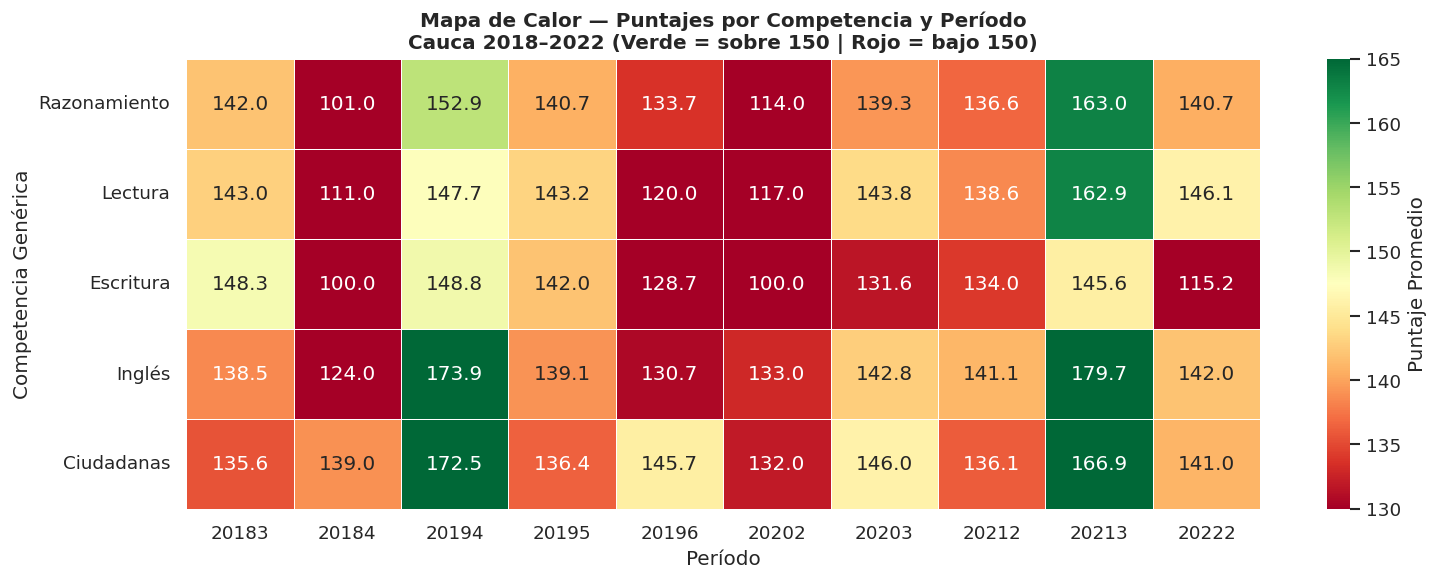

In [ ]:
# ─── Heatmap: puntajes por competencia y período ─────────────────────────────
# Vista matricial que permite comparar todas las combinaciones a la vez

heatmap_data = tendencia.set_index('PERIODO')[NOMBRES_PUNTAJES].T

plt.figure(figsize=(13, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5,
            vmin=130, vmax=165,
            cbar_kws={'label': 'Puntaje Promedio'})
plt.title('Mapa de Calor — Puntajes por Competencia y Período\n'
          'Cauca 2018–2022 (Verde = sobre 150 | Rojo = bajo 150)')
plt.xlabel('Período')
plt.ylabel('Competencia Genérica')
plt.tight_layout()
plt.show()

In [23]:
# ─── Variación primer vs último período ──────────────────────────────────────
print("=== VARIACIÓN PRIMER vs ÚLTIMO PERÍODO ===")
primer = tendencia.iloc[0]
ultimo = tendencia.iloc[-1]

variacion = pd.DataFrame({
    'Competencia': NOMBRES_PUNTAJES + ['Global'],
    f"Período {int(primer['PERIODO'])}": [primer[n] for n in NOMBRES_PUNTAJES + ['Global']],
    f"Período {int(ultimo['PERIODO'])}": [ultimo[n] for n in NOMBRES_PUNTAJES + ['Global']],
})
variacion['Variación'] = (
    variacion[f"Período {int(ultimo['PERIODO'])}"] -
    variacion[f"Período {int(primer['PERIODO'])}"]
).round(2)
variacion['Tendencia'] = variacion['Variación'].apply(
    lambda x: '📈 Mejora' if x > 0 else ('📉 Deterioro' if x < 0 else '➡️ Estable')
)
print(variacion.to_string(index=False))

# Año crítico
idx_min = tendencia_global['Promedio'].idxmin()
idx_max = tendencia_global['Promedio'].idxmax()
print(f"\n  📍 Período MÁS BAJO:  "
      f"{int(tendencia_global.loc[idx_min,'PERIODO'])} "
      f"({tendencia_global.loc[idx_min,'Promedio']:.2f} pts)")
print(f"  📍 Período MÁS ALTO:  "
      f"{int(tendencia_global.loc[idx_max,'PERIODO'])} "
      f"({tendencia_global.loc[idx_max,'Promedio']:.2f} pts)")

=== VARIACIÓN PRIMER vs ÚLTIMO PERÍODO ===
 Competencia  Período 20183  Período 20222  Variación   Tendencia
Razonamiento         142.03         140.66      -1.37 📉 Deterioro
     Lectura         142.97         146.13       3.16    📈 Mejora
   Escritura         148.34         115.15     -33.19 📉 Deterioro
      Inglés         138.53         141.97       3.44    📈 Mejora
  Ciudadanas         135.57         140.98       5.41    📈 Mejora
      Global         141.91         136.98      -4.93 📉 Deterioro

  📍 Período MÁS BAJO:  20184 (115.00 pts)
  📍 Período MÁS ALTO:  20213 (163.62 pts)


---
## 2.6 Relación entre puntajes y variables socioeconómicas

### Objetivo (OE2)
Explorar la asociación entre el desempeño en Saber Pro y el estrato
socioeconómico del estudiante universitario, identificando los perfiles
con mayor concentración de puntajes bajos.

### ¿Qué es el estrato en Colombia?
Sistema de clasificación 1–6 asignado a viviendas por el municipio.
Funciona como variable proxy del nivel socioeconómico.
En el Cauca predominan estratos 1 y 2, lo que refleja la realidad de pobreza estructural del departamento.

=== DISTRIBUCIÓN POR ESTRATO — CAUCA 2018–2022 ===
    ESTRATO  count     %
  Estrato 1   7218 35.04
  Estrato 2   6419 31.16
  Estrato 3   3823 18.56
       None   1281  6.22
  Estrato 4   1211  5.88
  Estrato 5    307  1.49
Sin Estrato    257  1.25
  Estrato 6     82  0.40


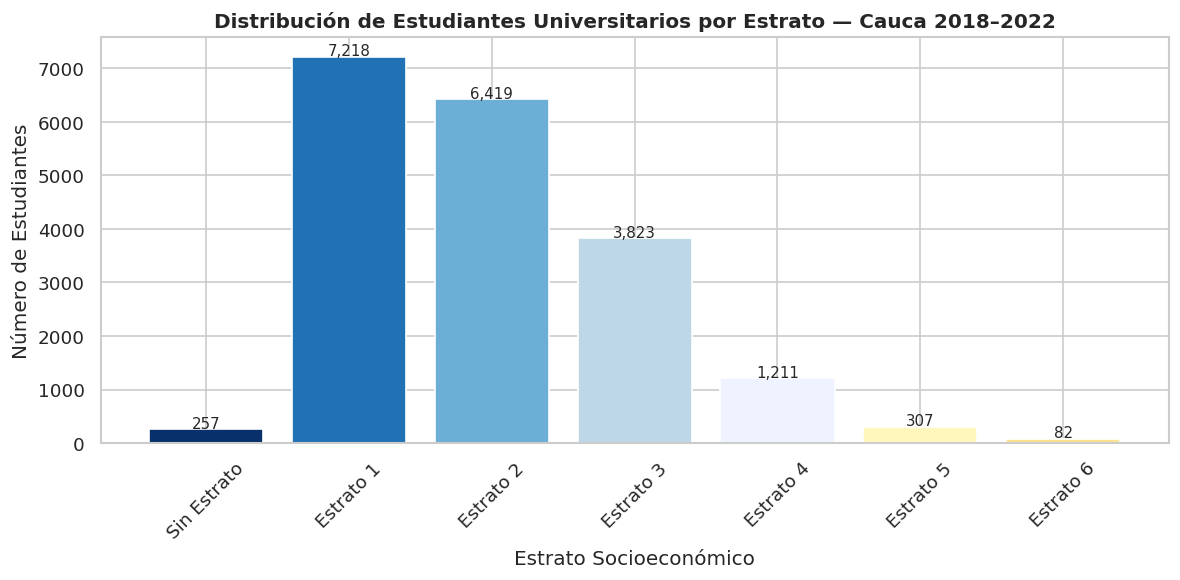

In [24]:
# ─── Distribución de estudiantes por estrato ─────────────────────────────────
ORDEN_ESTRATO = ['Sin Estrato','Estrato 1','Estrato 2','Estrato 3',
                 'Estrato 4','Estrato 5','Estrato 6']

estrato_dist = df_cauca.groupBy('ESTRATO') \
    .count() \
    .orderBy(F.desc('count')) \
    .toPandas()

print("=== DISTRIBUCIÓN POR ESTRATO — CAUCA 2018–2022 ===")
total_con_estrato = estrato_dist['count'].sum()
estrato_dist['%'] = (estrato_dist['count'] / total_con_estrato * 100).round(2)
print(estrato_dist.to_string(index=False))

# Gráfico
estrato_ord = estrato_dist.set_index('ESTRATO').reindex(ORDEN_ESTRATO).dropna()
plt.figure(figsize=(10, 5))
colores_e = ['#08306b','#2171b5','#6baed6','#bdd7e7','#eff3ff','#fff7bc','#fee391'][:len(estrato_ord)]
bars = plt.bar(estrato_ord.index, estrato_ord['count'],
               color=colores_e, edgecolor='white')
plt.title('Distribución de Estudiantes Universitarios por Estrato — Cauca 2018–2022')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Número de Estudiantes')
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(bar.get_height()):,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

=== PUNTAJE GLOBAL PROMEDIO POR ESTRATO ===
             Promedio     N  Brecha
ESTRATO                            
Sin Estrato    130.96   254   19.04
Estrato 1      136.18  7139   13.82
Estrato 2      140.94  6361    9.06
Estrato 3      143.57  3770    6.43
Estrato 4      150.69  1198   -0.69
Estrato 5      149.33   306    0.67
Estrato 6      143.25    81    6.75


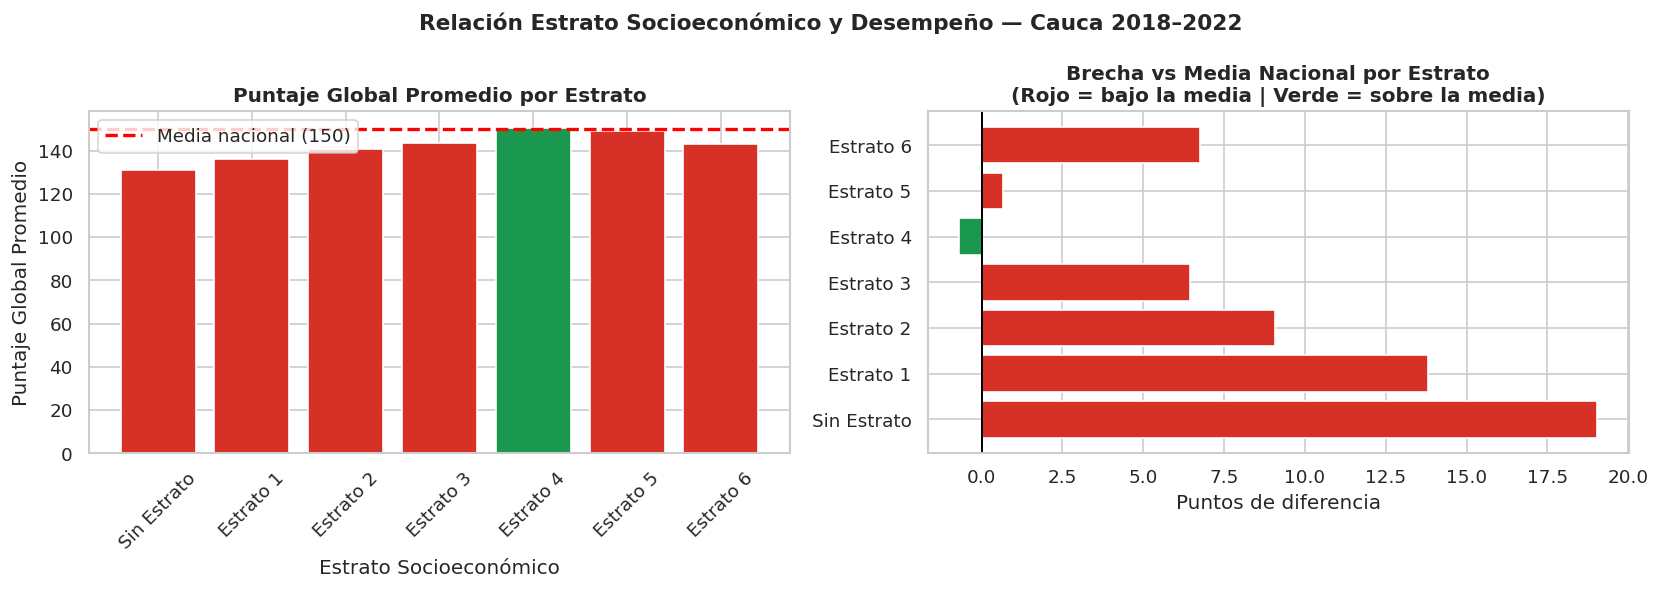

In [25]:
# ─── Puntaje global promedio por estrato ─────────────────────────────────────
estrato_punt = df_cauca.groupBy('ESTRATO') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio'),
         F.count('PUNT_GLOBAL').alias('N')) \
    .toPandas().set_index('ESTRATO').reindex(ORDEN_ESTRATO).dropna()

print("=== PUNTAJE GLOBAL PROMEDIO POR ESTRATO ===")
estrato_punt['Brecha'] = (MEDIA_NACIONAL - estrato_punt['Promedio']).round(2)
print(estrato_punt.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de promedio
colores_ep = ['#d73027' if v < MEDIA_NACIONAL else '#1a9850'
              for v in estrato_punt['Promedio']]
axes[0].bar(estrato_punt.index, estrato_punt['Promedio'],
            color=colores_ep, edgecolor='white')
axes[0].axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
axes[0].set_title('Puntaje Global Promedio por Estrato')
axes[0].set_xlabel('Estrato Socioeconómico')
axes[0].set_ylabel('Puntaje Global Promedio')
axes[0].set_xticklabels(estrato_punt.index, rotation=45)
axes[0].legend()

# Brecha vs nacional
colores_eb = ['#d73027' if b > 0 else '#1a9850' for b in estrato_punt['Brecha']]
axes[1].barh(estrato_punt.index, estrato_punt['Brecha'], color=colores_eb)
axes[1].axvline(x=0, color='black', linewidth=1.2)
axes[1].set_title('Brecha vs Media Nacional por Estrato\n'
                  '(Rojo = bajo la media | Verde = sobre la media)')
axes[1].set_xlabel('Puntos de diferencia')

plt.suptitle('Relación Estrato Socioeconómico y Desempeño — Cauca 2018–2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

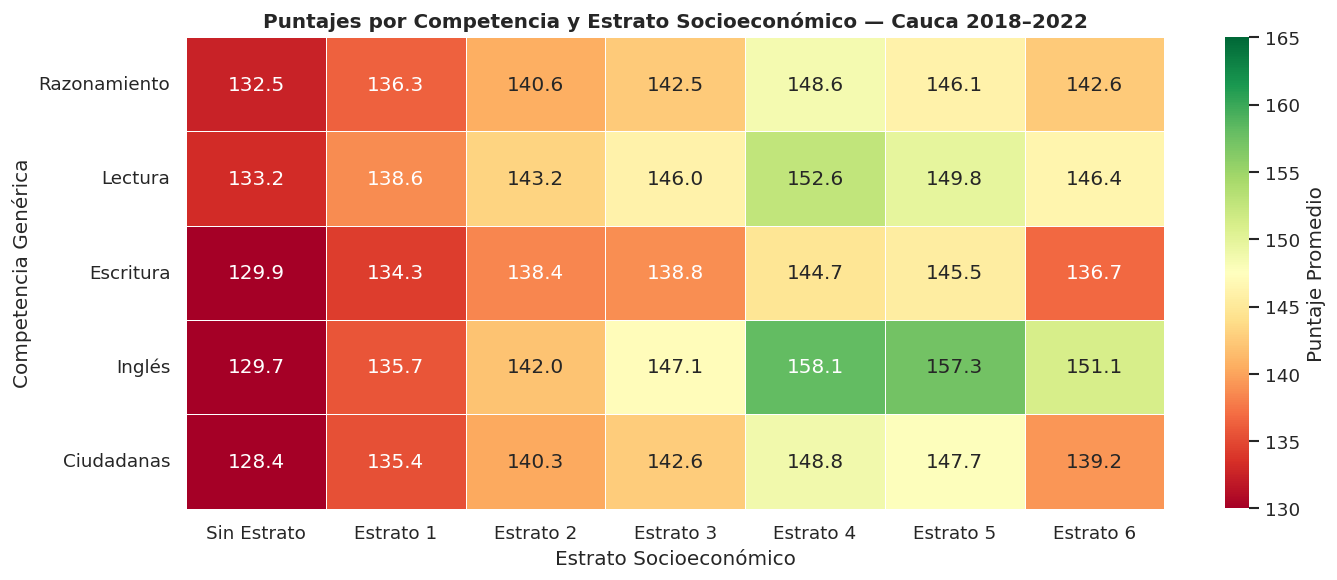

In [26]:
# ─── Heatmap: competencias por estrato ───────────────────────────────────────
estrato_comp = df_cauca.groupBy('ESTRATO').agg(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)]
).toPandas().set_index('ESTRATO').reindex(ORDEN_ESTRATO).dropna()

plt.figure(figsize=(12, 5))
sns.heatmap(estrato_comp.T, annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=130, vmax=165,
            linewidths=0.5, cbar_kws={'label': 'Puntaje Promedio'})
plt.title('Puntajes por Competencia y Estrato Socioeconómico — Cauca 2018–2022')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Competencia Genérica')
plt.tight_layout()
plt.show()

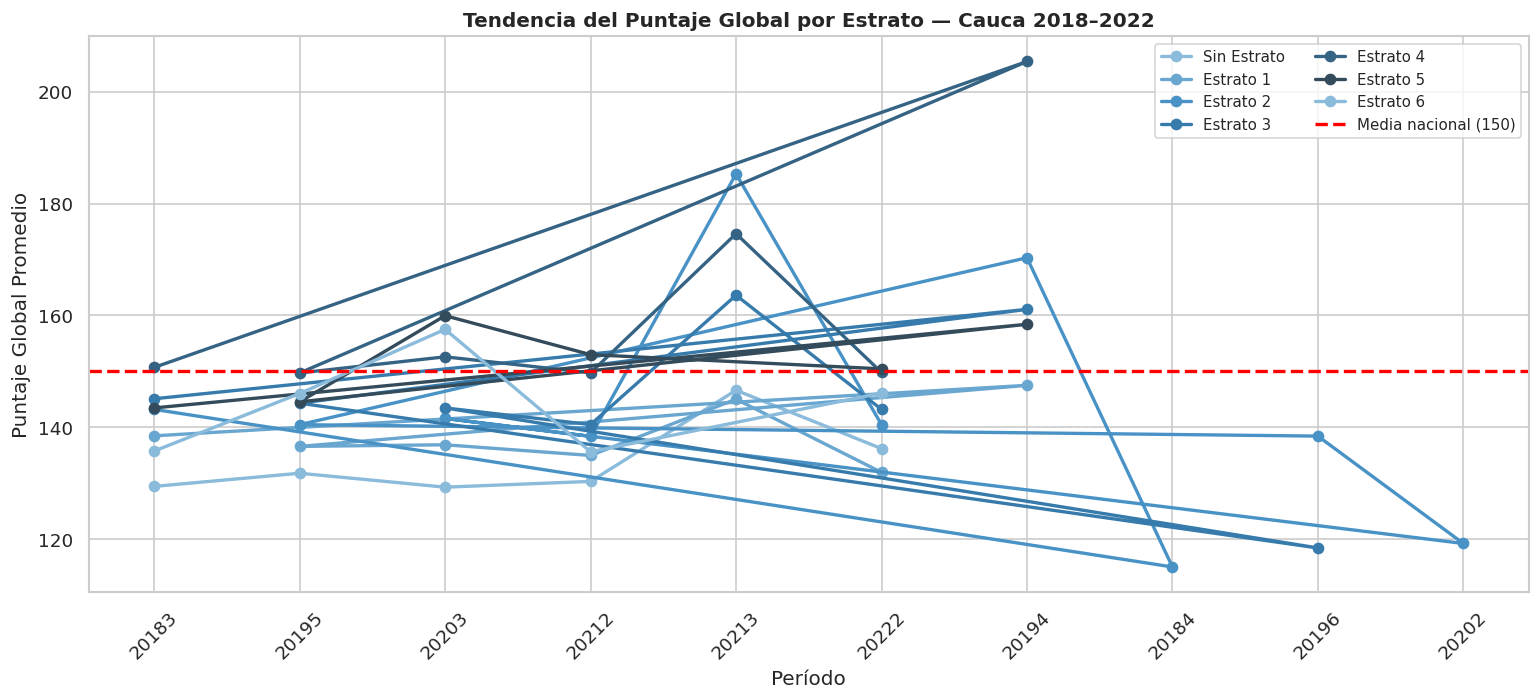

In [27]:
# ─── Tendencia del puntaje global por estrato y período ──────────────────────
plt.figure(figsize=(13, 6))

for estrato in ORDEN_ESTRATO:
    datos_est = df_cauca.filter(F.col('ESTRATO') == estrato) \
        .groupBy('PERIODO') \
        .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio')) \
        .orderBy('PERIODO').toPandas()

    if len(datos_est) > 0:
        plt.plot(datos_est['PERIODO'].astype(str),
                 datos_est['Promedio'],
                 marker='o', linewidth=2, label=estrato, markersize=6)

plt.axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
            label='Media nacional (150)', zorder=2)
plt.title('Tendencia del Puntaje Global por Estrato — Cauca 2018–2022')
plt.xlabel('Período')
plt.ylabel('Puntaje Global Promedio')
plt.legend(loc='upper right', fontsize=9, ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 2.7 Relación entre puntajes y variables familiares

### Objetivo (OE2)
Explorar cómo el nivel educativo de los padres se asocia con el desempeño
universitario en Saber Pro, operacionalizando el concepto de **capital cultural**
de Bourdieu y Passeron: a mayor nivel educativo de los padres,
mayor es el capital cultural transmitido al estudiante universitario.

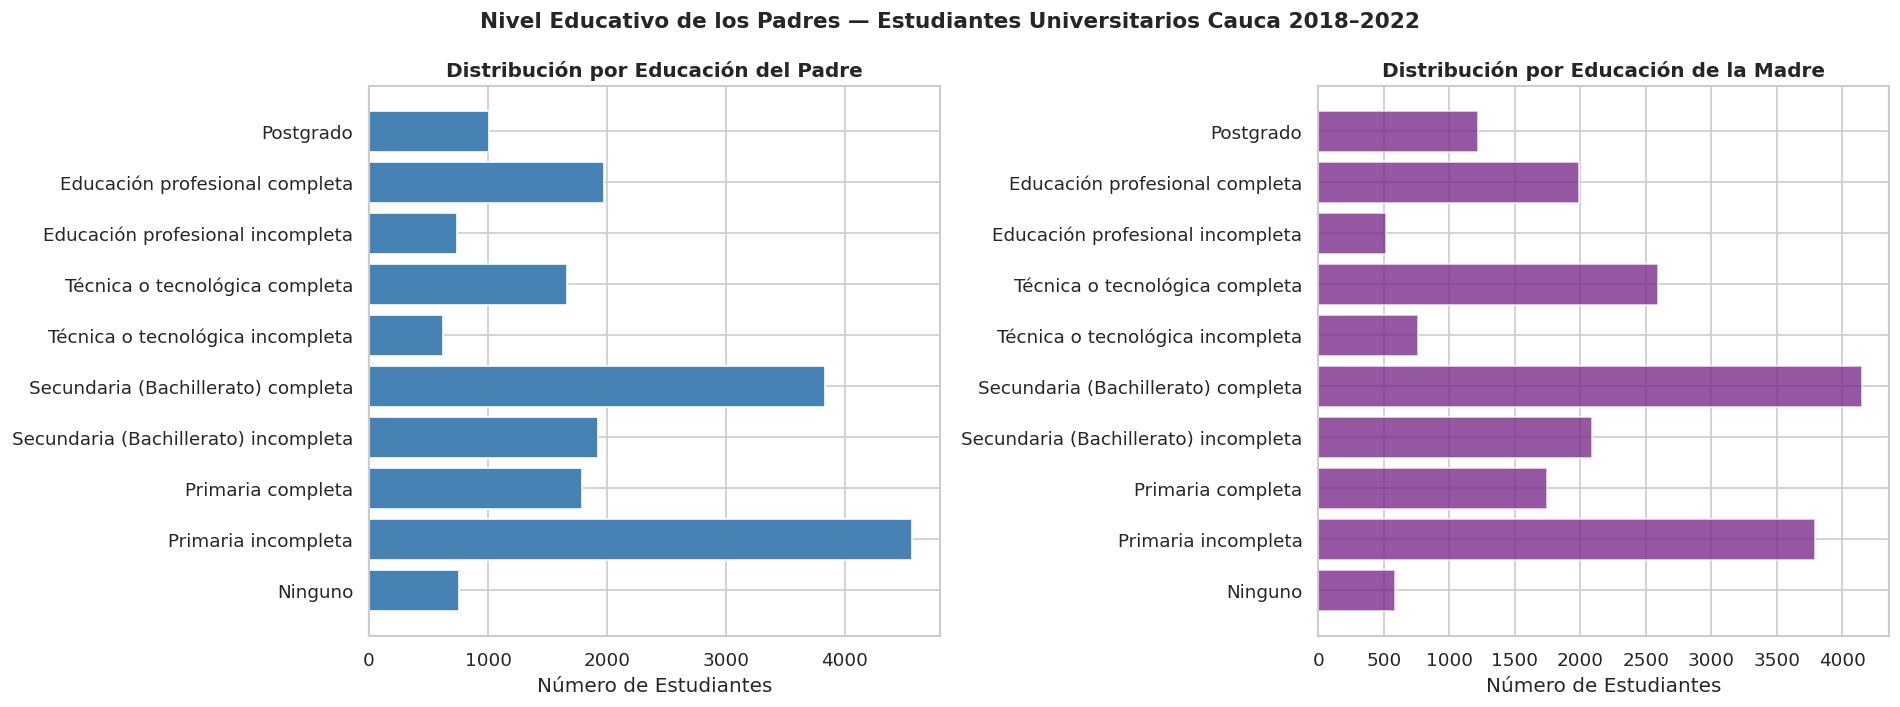

In [28]:
# ─── Orden jerárquico de niveles educativos ───────────────────────────────────
ORDEN_EDUC = [
    'Ninguno',
    'Primaria incompleta',
    'Primaria completa',
    'Secundaria (Bachillerato) incompleta',
    'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta',
    'Técnica o tecnológica completa',
    'Educación profesional incompleta',
    'Educación profesional completa',
    'Postgrado'
]

# ─── Distribución de estudiantes por educación del padre ─────────────────────
padre_dist = df_cauca.groupBy('EDUC_PADRE').count() \
    .toPandas().set_index('EDUC_PADRE').reindex(ORDEN_EDUC).dropna()

madre_dist = df_cauca.groupBy('EDUC_MADRE').count() \
    .toPandas().set_index('EDUC_MADRE').reindex(ORDEN_EDUC).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(padre_dist.index, padre_dist['count'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribución por Educación del Padre')
axes[0].set_xlabel('Número de Estudiantes')

axes[1].barh(madre_dist.index, madre_dist['count'],
             color='#7b2d8b', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución por Educación de la Madre')
axes[1].set_xlabel('Número de Estudiantes')

plt.suptitle('Nivel Educativo de los Padres — Estudiantes Universitarios Cauca 2018–2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

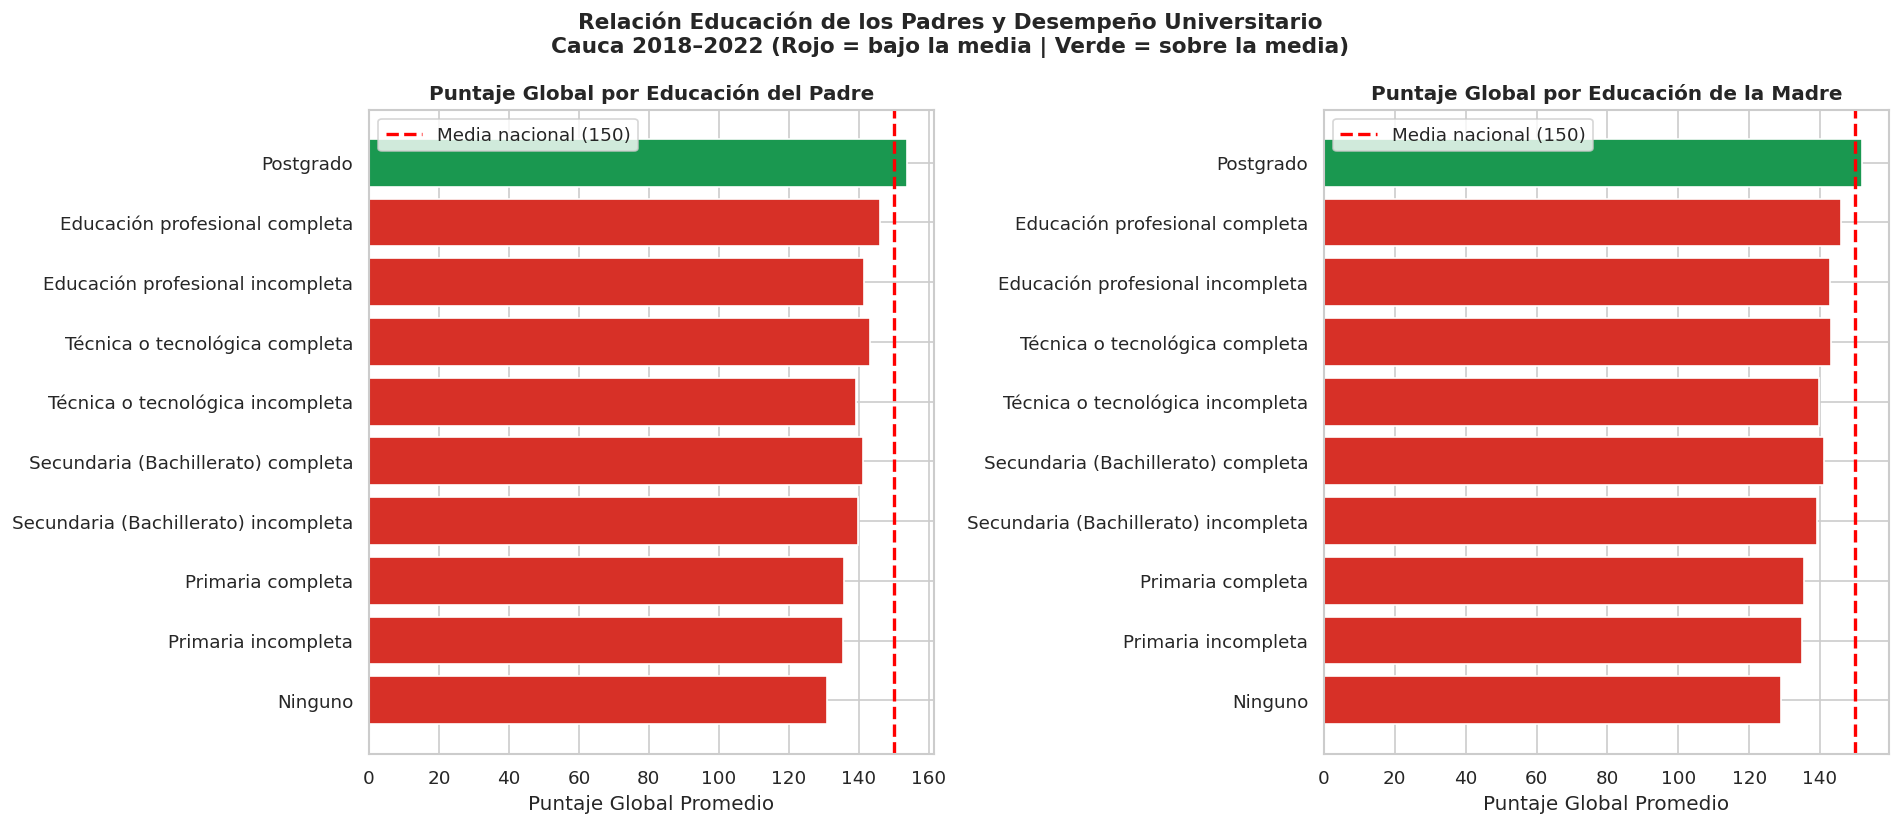

In [29]:
# ─── Puntaje global por educación padre y madre ──────────────────────────────
padre_punt = df_cauca.groupBy('EDUC_PADRE') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio')) \
    .toPandas().set_index('EDUC_PADRE').reindex(ORDEN_EDUC).dropna()

madre_punt = df_cauca.groupBy('EDUC_MADRE') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio')) \
    .toPandas().set_index('EDUC_MADRE').reindex(ORDEN_EDUC).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Padre
colores_p = ['#d73027' if v < MEDIA_NACIONAL else '#1a9850'
             for v in padre_punt['Promedio']]
axes[0].barh(padre_punt.index, padre_punt['Promedio'],
             color=colores_p, edgecolor='white')
axes[0].axvline(x=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
axes[0].set_title('Puntaje Global por Educación del Padre')
axes[0].set_xlabel('Puntaje Global Promedio')
axes[0].legend()

# Madre
colores_m = ['#d73027' if v < MEDIA_NACIONAL else '#1a9850'
             for v in madre_punt['Promedio']]
axes[1].barh(madre_punt.index, madre_punt['Promedio'],
             color=colores_m, edgecolor='white')
axes[1].axvline(x=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
axes[1].set_title('Puntaje Global por Educación de la Madre')
axes[1].set_xlabel('Puntaje Global Promedio')
axes[1].legend()

plt.suptitle('Relación Educación de los Padres y Desempeño Universitario\n'
             'Cauca 2018–2022 (Rojo = bajo la media | Verde = sobre la media)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

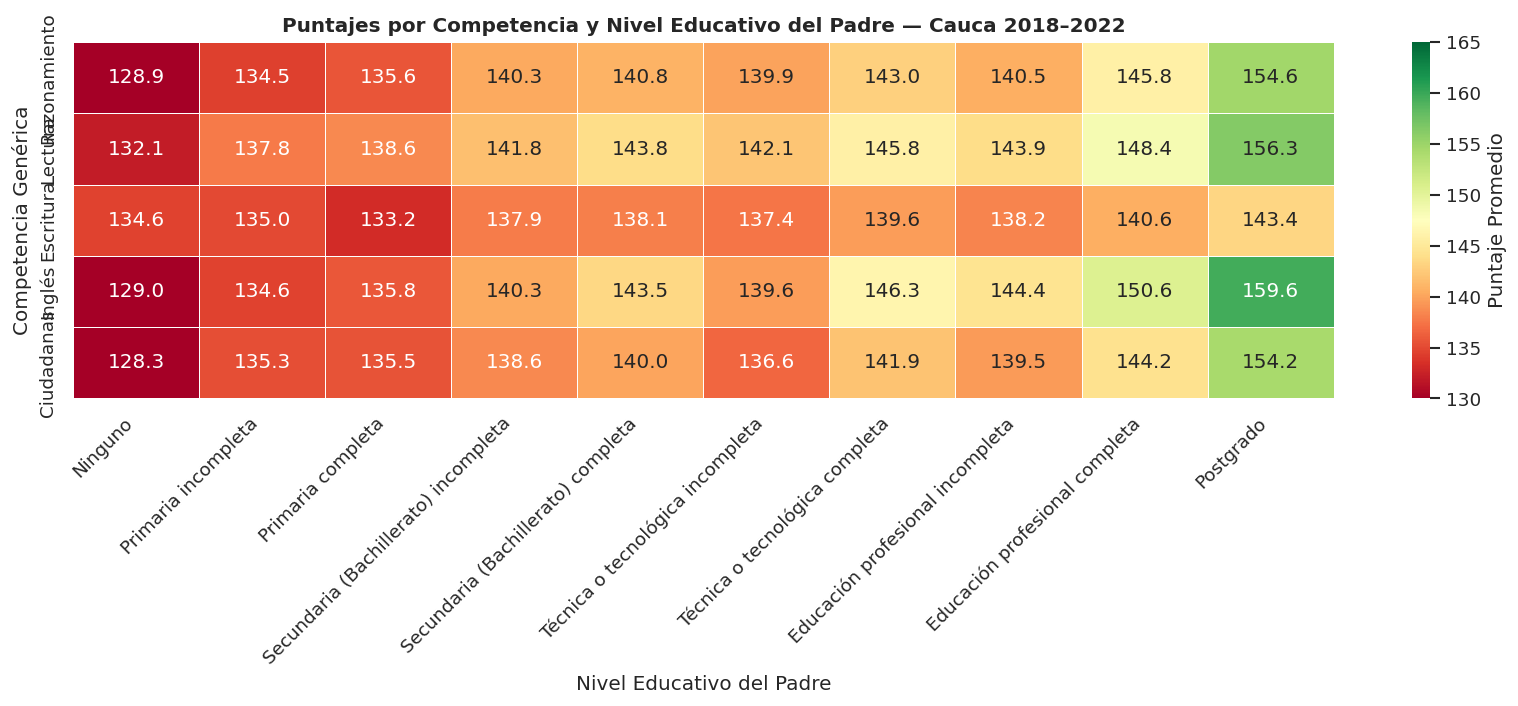

In [30]:
# ─── Heatmap: competencias por educación del padre ───────────────────────────
padre_comp = df_cauca.groupBy('EDUC_PADRE').agg(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)]
).toPandas().set_index('EDUC_PADRE').reindex(ORDEN_EDUC).dropna()

plt.figure(figsize=(14, 6))
sns.heatmap(padre_comp.T, annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=130, vmax=165,
            linewidths=0.5, cbar_kws={'label': 'Puntaje Promedio'})
plt.title('Puntajes por Competencia y Nivel Educativo del Padre — Cauca 2018–2022')
plt.xlabel('Nivel Educativo del Padre')
plt.ylabel('Competencia Genérica')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# ─── Comparación padre vs madre ──────────────────────────────────────────────
print("=== COMPARACIÓN PADRE VS MADRE — PUNTAJE GLOBAL PROMEDIO ===")

# Alinear índices
niveles_comunes = padre_punt.index.intersection(madre_punt.index)
comp_familiar = pd.DataFrame({
    'Nivel Educativo': niveles_comunes,
    'Promedio Padre':  padre_punt.loc[niveles_comunes, 'Promedio'].values,
    'Promedio Madre':  madre_punt.loc[niveles_comunes, 'Promedio'].values,
})
comp_familiar['Diferencia (P-M)'] = (
    comp_familiar['Promedio Padre'] - comp_familiar['Promedio Madre']
).round(2)
print(comp_familiar.to_string(index=False))

=== COMPARACIÓN PADRE VS MADRE — PUNTAJE GLOBAL PROMEDIO ===
                     Nivel Educativo  Promedio Padre  Promedio Madre  Diferencia (P-M)
                             Ninguno          130.82          128.85              1.97
                 Primaria incompleta          135.50          135.04              0.46
                   Primaria completa          135.88          135.39              0.49
Secundaria (Bachillerato) incompleta          139.86          139.28              0.58
  Secundaria (Bachillerato) completa          141.31          141.26              0.05
    Técnica o tecnológica incompleta          139.26          139.78             -0.52
      Técnica o tecnológica completa          143.34          143.19              0.15
    Educación profesional incompleta          141.47          142.71             -1.24
      Educación profesional completa          145.96          145.99             -0.03
                           Postgrado          153.78          151.82 

---
## 2.8 Relación entre puntajes y condiciones laborales

### Objetivo (OE2)
Analizar cómo las horas dedicadas al trabajo semanal se asocian con el
desempeño en Saber Pro. Esta variable es clave en el Cauca donde muchos
estudiantes universitarios deben trabajar para financiar sus estudios,
reduciendo el tiempo de dedicación académica.

=== DISTRIBUCIÓN POR HORAS DE TRABAJO SEMANAL ===
                      count     %
HORAS_TRABAJO                    
Entre 11 y 20 horas  4412.0  35.7
Entre 21 y 30 horas  2893.0  23.4
Más de 30 horas      5039.0  40.8


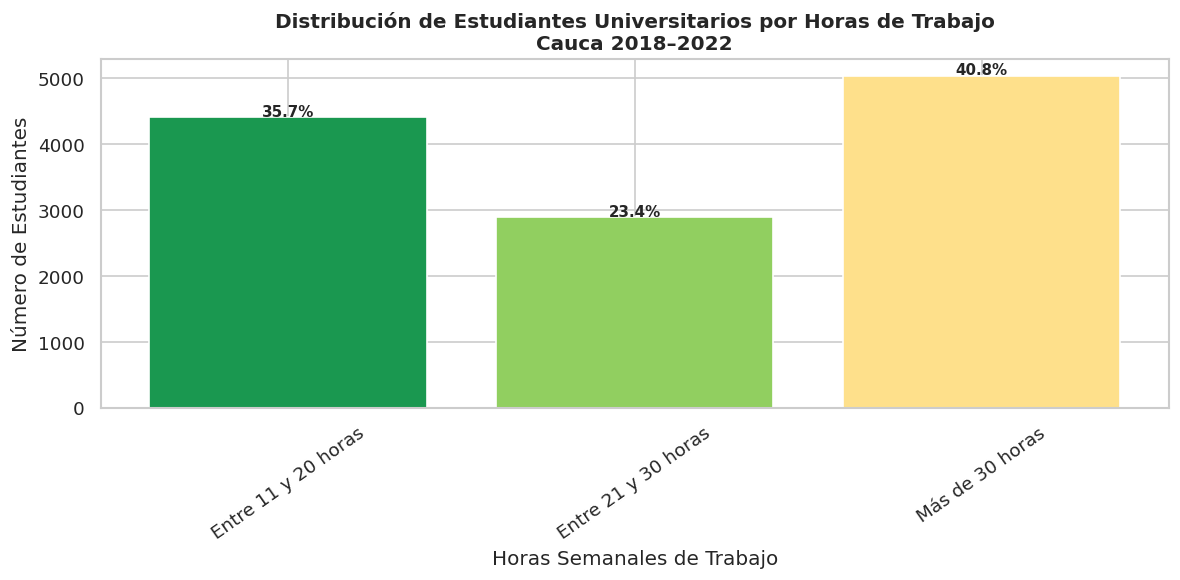

In [32]:
# ─── Distribución por horas de trabajo ───────────────────────────────────────
ORDEN_HORAS = ['0 horas','Entre 1 y 10 horas','Entre 11 y 20 horas',
               'Entre 21 y 30 horas','Más de 30 horas']

horas_dist = df_cauca.groupBy('HORAS_TRABAJO').count() \
    .toPandas().set_index('HORAS_TRABAJO').reindex(ORDEN_HORAS).dropna()

horas_dist['%'] = (horas_dist['count'] / horas_dist['count'].sum() * 100).round(1)

print("=== DISTRIBUCIÓN POR HORAS DE TRABAJO SEMANAL ===")
print(horas_dist.to_string())

plt.figure(figsize=(10, 5))
colores_h = ['#1a9850','#91cf60','#fee08b','#fc8d59','#d73027'][:len(horas_dist)]
bars = plt.bar(horas_dist.index, horas_dist['count'],
               color=colores_h, edgecolor='white')
for bar, pct in zip(bars, horas_dist['%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.title('Distribución de Estudiantes Universitarios por Horas de Trabajo\n'
          'Cauca 2018–2022')
plt.xlabel('Horas Semanales de Trabajo')
plt.ylabel('Número de Estudiantes')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

=== PUNTAJE GLOBAL PROMEDIO POR HORAS DE TRABAJO ===
                     Promedio       N  Brecha
HORAS_TRABAJO                                
Entre 11 y 20 horas    139.73  4367.0   10.27
Entre 21 y 30 horas    138.64  2858.0   11.36
Más de 30 horas        138.48  4984.0   11.52


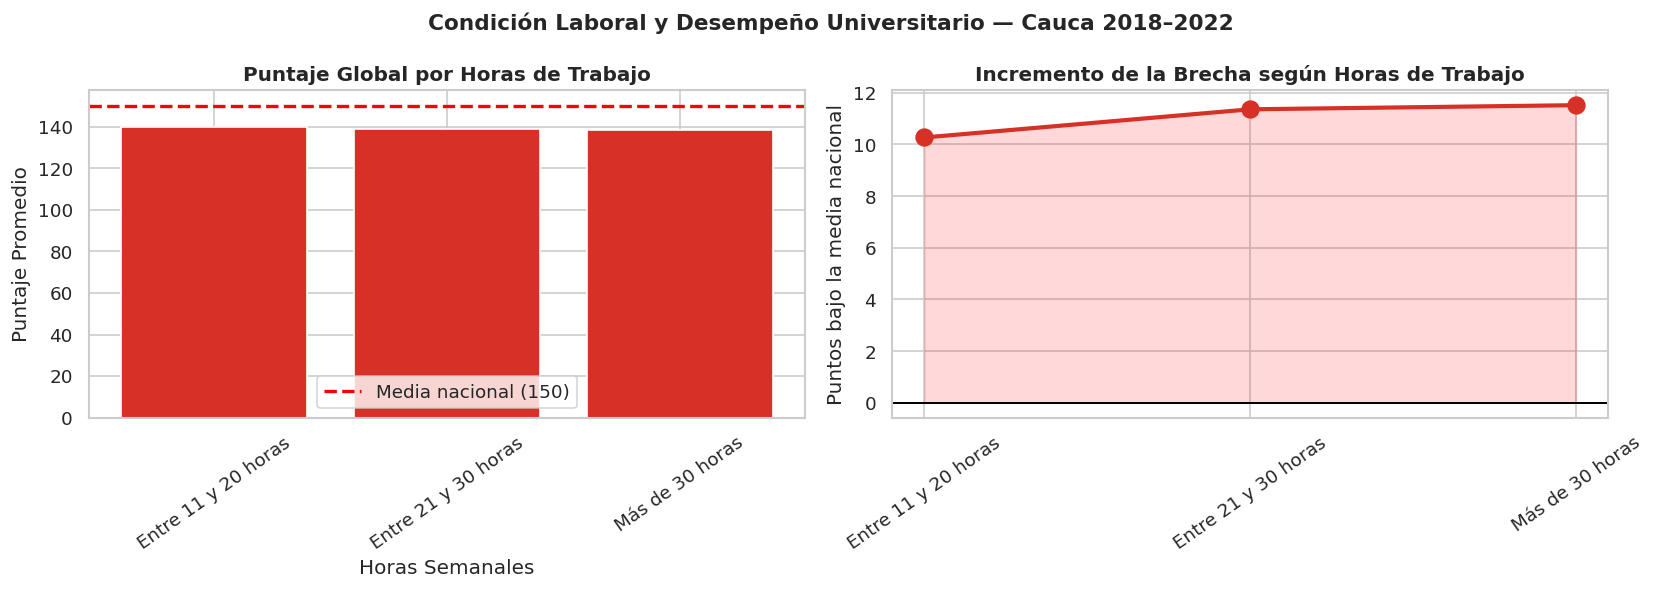

In [33]:
# ─── Puntaje global por horas de trabajo ─────────────────────────────────────
horas_punt = df_cauca.groupBy('HORAS_TRABAJO') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio'),
         F.count('PUNT_GLOBAL').alias('N')) \
    .toPandas().set_index('HORAS_TRABAJO').reindex(ORDEN_HORAS).dropna()

horas_punt['Brecha'] = (MEDIA_NACIONAL - horas_punt['Promedio']).round(2)

print("=== PUNTAJE GLOBAL PROMEDIO POR HORAS DE TRABAJO ===")
print(horas_punt.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de promedio
colores_hp = ['#1a9850' if v >= MEDIA_NACIONAL else '#d73027'
              for v in horas_punt['Promedio']]
axes[0].bar(horas_punt.index, horas_punt['Promedio'],
            color=colores_hp, edgecolor='white')
axes[0].axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
axes[0].set_title('Puntaje Global por Horas de Trabajo')
axes[0].set_xlabel('Horas Semanales')
axes[0].set_ylabel('Puntaje Promedio')
axes[0].set_xticklabels(horas_punt.index, rotation=35)
axes[0].legend()

# Línea de tendencia de la brecha
axes[1].plot(range(len(horas_punt)), horas_punt['Brecha'],
             marker='o', color='#d73027', linewidth=2.5, markersize=10)
axes[1].axhline(y=0, color='black', linewidth=1.2)
axes[1].fill_between(range(len(horas_punt)), horas_punt['Brecha'], 0,
                     where=(horas_punt['Brecha'] > 0),
                     alpha=0.15, color='red')
axes[1].set_xticks(range(len(horas_punt)))
axes[1].set_xticklabels(horas_punt.index, rotation=35)
axes[1].set_title('Incremento de la Brecha según Horas de Trabajo')
axes[1].set_ylabel('Puntos bajo la media nacional')

plt.suptitle('Condición Laboral y Desempeño Universitario — Cauca 2018–2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Brecha clave
no_trabaja = horas_punt.loc['0 horas','Promedio'] if '0 horas' in horas_punt.index else None
mas_30     = horas_punt.loc['Más de 30 horas','Promedio'] if 'Más de 30 horas' in horas_punt.index else None
if no_trabaja and mas_30:
    print(f"\n  📊 Brecha clave: no trabaja vs +30 hrs/semana")
    print(f"     Sin trabajo:     {no_trabaja:.2f} puntos")
    print(f"     Más de 30 hrs:   {mas_30:.2f} puntos")
    print(f"     Diferencia:      {no_trabaja - mas_30:.2f} puntos")

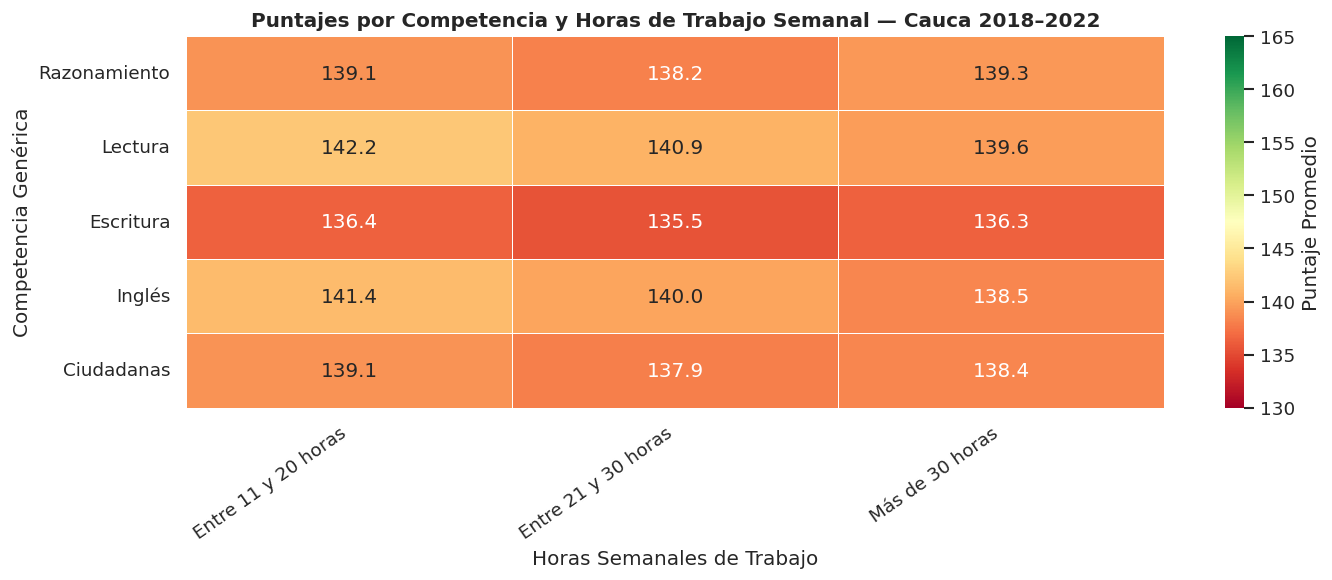

In [34]:
# ─── Heatmap: competencias por horas de trabajo ──────────────────────────────
horas_comp = df_cauca.groupBy('HORAS_TRABAJO').agg(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)]
).toPandas().set_index('HORAS_TRABAJO').reindex(ORDEN_HORAS).dropna()

plt.figure(figsize=(12, 5))
sns.heatmap(horas_comp.T, annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=130, vmax=165,
            linewidths=0.5, cbar_kws={'label': 'Puntaje Promedio'})
plt.title('Puntajes por Competencia y Horas de Trabajo Semanal — Cauca 2018–2022')
plt.xlabel('Horas Semanales de Trabajo')
plt.ylabel('Competencia Genérica')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

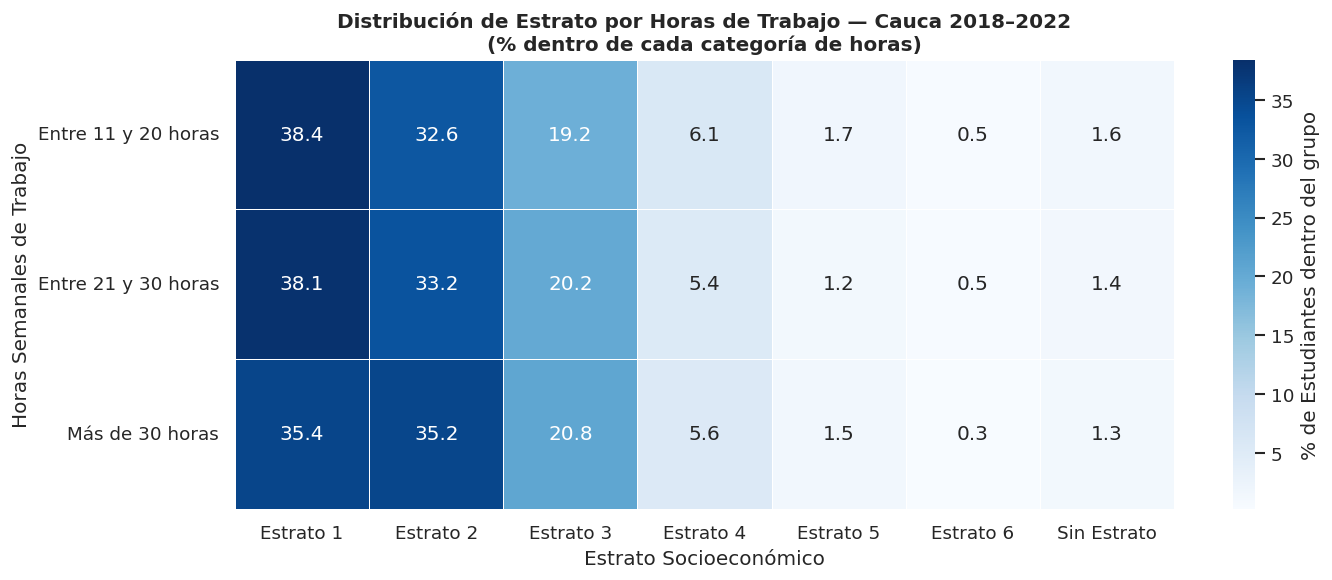

In [35]:
# ─── Relación horas de trabajo vs estrato ────────────────────────────────────
# Permite ver si los estudiantes de estratos bajos trabajan más horas
# Operacionaliza la teoría de reproducción social de Bourdieu

cruce = df_cauca.groupBy('HORAS_TRABAJO','ESTRATO').count() \
    .toPandas()
cruce_pivot = cruce.pivot_table(
    index='HORAS_TRABAJO', columns='ESTRATO', values='count', fill_value=0
)
# Normalizar por fila (% dentro de cada grupo de horas)
cruce_pct = cruce_pivot.div(cruce_pivot.sum(axis=1), axis=0).round(3) * 100
cruce_pct = cruce_pct.reindex(ORDEN_HORAS).dropna()

plt.figure(figsize=(12, 5))
sns.heatmap(cruce_pct, annot=True, fmt='.1f',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': '% de Estudiantes dentro del grupo'})
plt.title('Distribución de Estrato por Horas de Trabajo — Cauca 2018–2022\n'
          '(% dentro de cada categoría de horas)')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Horas Semanales de Trabajo')
plt.tight_layout()
plt.show()

---
## 2.9 Análisis de diferencias por tipo de institución y municipio

### Objetivo (OE3)
Comparar el desempeño en Saber Pro entre municipios del Cauca y según el
carácter de la IES (oficial vs. privada), cuantificando la magnitud de las
brechas por competencia genérica e identificando los territorios con mayor
rezago respecto al promedio departamental.

### Cruce con DIVIPOLA
El dataset Saber Pro contiene el código DANE del municipio pero no el nombre.
Cruzamos con DIVIPOLA (DANE) para obtener los nombres y poder visualizar correctamente.

In [36]:
# ─── Cargar y cruzar con DIVIPOLA ────────────────────────────────────────────
divipola_pd = pd.read_csv(RUTA_DIVIPOLA)

# Filtrar solo municipios del Cauca y renombrar columnas
divipola_cauca = divipola_pd[
    divipola_pd['Nombre Departamento'] == 'CAUCA'
].copy().rename(columns={
    'Código Municipio': 'COD_MUNICIPIO',
    'Nombre Municipio': 'NOMBRE_MUNICIPIO'
})[['COD_MUNICIPIO','NOMBRE_MUNICIPIO']]

divipola_cauca['COD_MUNICIPIO'] = divipola_cauca['COD_MUNICIPIO'].astype(int)

print(f"✅ DIVIPOLA cargada — {len(divipola_cauca)} municipios del Cauca")
print(divipola_cauca.head(10).to_string(index=False))

# Convertir a Spark DataFrame para el JOIN
divipola_spark = spark.createDataFrame(divipola_cauca)

# JOIN con el dataset principal (left join: conserva todos los registros del Cauca)
df_cauca = df_cauca.join(divipola_spark, on='COD_MUNICIPIO', how='left')
df_cauca.cache()

municipios_encontrados = df_cauca.filter(
    F.col('NOMBRE_MUNICIPIO').isNotNull()
).select('NOMBRE_MUNICIPIO').distinct().count()

print(f"\n✅ Municipios del Cauca identificados: {municipios_encontrados}")

✅ DIVIPOLA cargada — 42 municipios del Cauca
 COD_MUNICIPIO NOMBRE_MUNICIPIO
         19001          POPAYÁN
         19022         ALMAGUER
         19050          ARGELIA
         19075           BALBOA
         19100          BOLÍVAR
         19110     BUENOS AIRES
         19130          CAJIBÍO
         19137          CALDONO
         19142           CALOTO
         19212          CORINTO

✅ Municipios del Cauca identificados: 42


=== DISTRIBUCIÓN POR ORIGEN DE IES ===
              ORIGEN_IES  count    %
        OFICIAL NACIONAL   8206 39.8
  NO OFICIAL - FUNDACIÓN   5697 27.7
NO OFICIAL - CORPORACIÓN   5237 25.4
   OFICIAL DEPARTAMENTAL   1005  4.9
       OFICIAL MUNICIPAL    452  2.2
        REGIMEN ESPECIAL      1  0.0


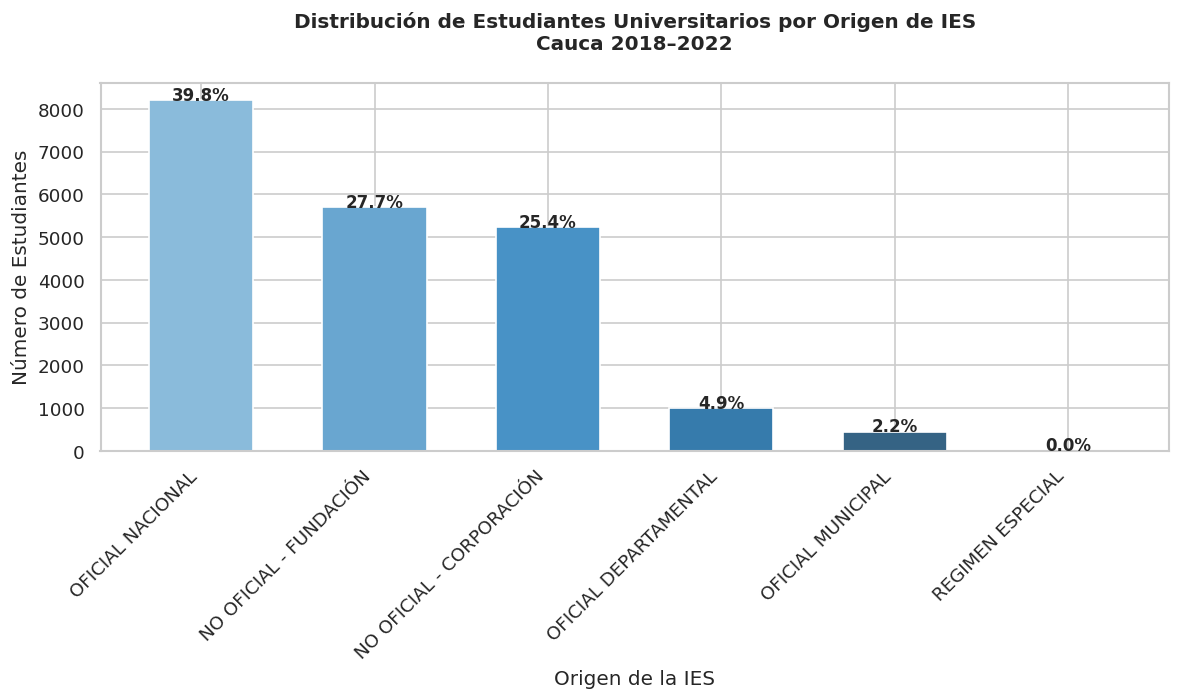

In [37]:
# ─── Distribución de estudiantes por origen de IES ───────────────────────────
from pyspark.sql import functions as F

origen_dist = df_cauca.groupBy('ORIGEN_IES') \
    .count().orderBy(F.desc('count')).toPandas()

print("=== DISTRIBUCIÓN POR ORIGEN DE IES ===")
origen_dist['%'] = (origen_dist['count'] / origen_dist['count'].sum() * 100).round(1)
print(origen_dist.to_string(index=False))

# Aumentamos un poco el alto (6) para que quepan los nombres inclinados
plt.figure(figsize=(10, 6))

# Usamos una paleta de colores automática para que no falle si hay más categorías
colores_ies = sns.color_palette("Blues_d", len(origen_dist))

bars = plt.bar(origen_dist['ORIGEN_IES'], origen_dist['count'],
               color=colores_ies, edgecolor='white', width=0.6)

for bar, pct in zip(bars, origen_dist['%']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.title('Distribución de Estudiantes Universitarios por Origen de IES\n'
          'Cauca 2018–2022', pad=20)
plt.xlabel('Origen de la IES')
plt.ylabel('Número de Estudiantes')

# --- ESTA ES LA MEJORA CLAVE ---
plt.xticks(rotation=45, ha='right') # Rotación diagonal y alineación a la derecha
# -------------------------------

plt.tight_layout() # Ajusta automáticamente los márgenes para que no se corte el texto
plt.show()

=== PUNTAJE GLOBAL: OFICIAL VS PRIVADA ===
              ORIGEN_IES  Promedio  Estudiantes  Brecha vs Nacional
NO OFICIAL - CORPORACIÓN    135.77         5169               14.23
       OFICIAL MUNICIPAL    123.69          449               26.31
        OFICIAL NACIONAL    149.50         8109                0.50
  NO OFICIAL - FUNDACIÓN    131.39         5641               18.61
   OFICIAL DEPARTAMENTAL    138.60          994               11.40
        REGIMEN ESPECIAL    137.20            1               12.80


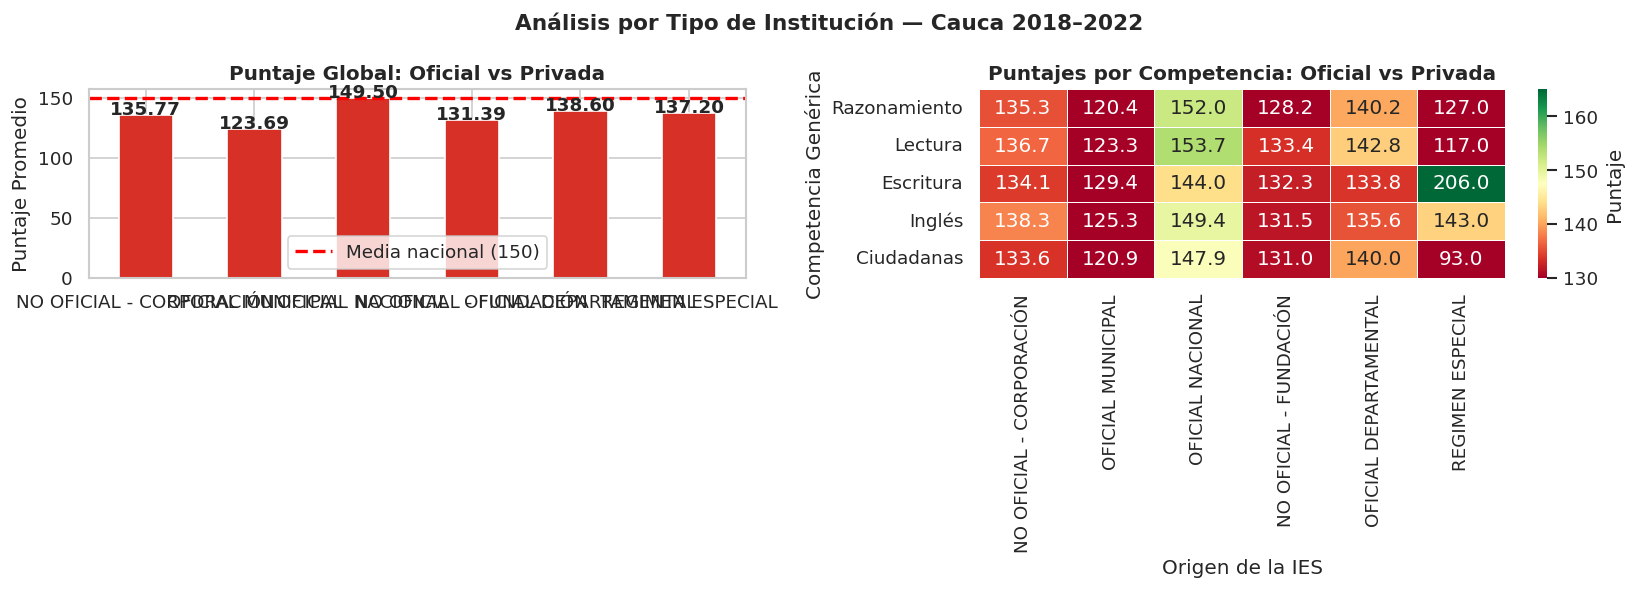

In [38]:
# ─── Puntaje global: oficial vs privada ──────────────────────────────────────
origen_punt = df_cauca.groupBy('ORIGEN_IES') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio'),
         F.count('PUNT_GLOBAL').alias('Estudiantes')) \
    .toPandas()

print("=== PUNTAJE GLOBAL: OFICIAL VS PRIVADA ===")
origen_punt['Brecha vs Nacional'] = (MEDIA_NACIONAL - origen_punt['Promedio']).round(2)
print(origen_punt.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de promedio
colores_op = ['#d73027' if v < MEDIA_NACIONAL else '#1a9850'
              for v in origen_punt['Promedio']]
axes[0].bar(origen_punt['ORIGEN_IES'], origen_punt['Promedio'],
            color=colores_op, edgecolor='white', width=0.5)
axes[0].axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
                label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
for i, row in origen_punt.iterrows():
    axes[0].text(i, row['Promedio'] + 0.3, f"{row['Promedio']:.2f}",
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Puntaje Global: Oficial vs Privada')
axes[0].set_ylabel('Puntaje Promedio')
axes[0].legend()

# Heatmap de competencias
origen_comp = df_cauca.groupBy('ORIGEN_IES').agg(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)]
).toPandas().set_index('ORIGEN_IES')

sns.heatmap(origen_comp.T, annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=130, vmax=165,
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Puntaje'})
axes[1].set_title('Puntajes por Competencia: Oficial vs Privada')
axes[1].set_xlabel('Origen de la IES')
axes[1].set_ylabel('Competencia Genérica')

plt.suptitle('Análisis por Tipo de Institución — Cauca 2018–2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

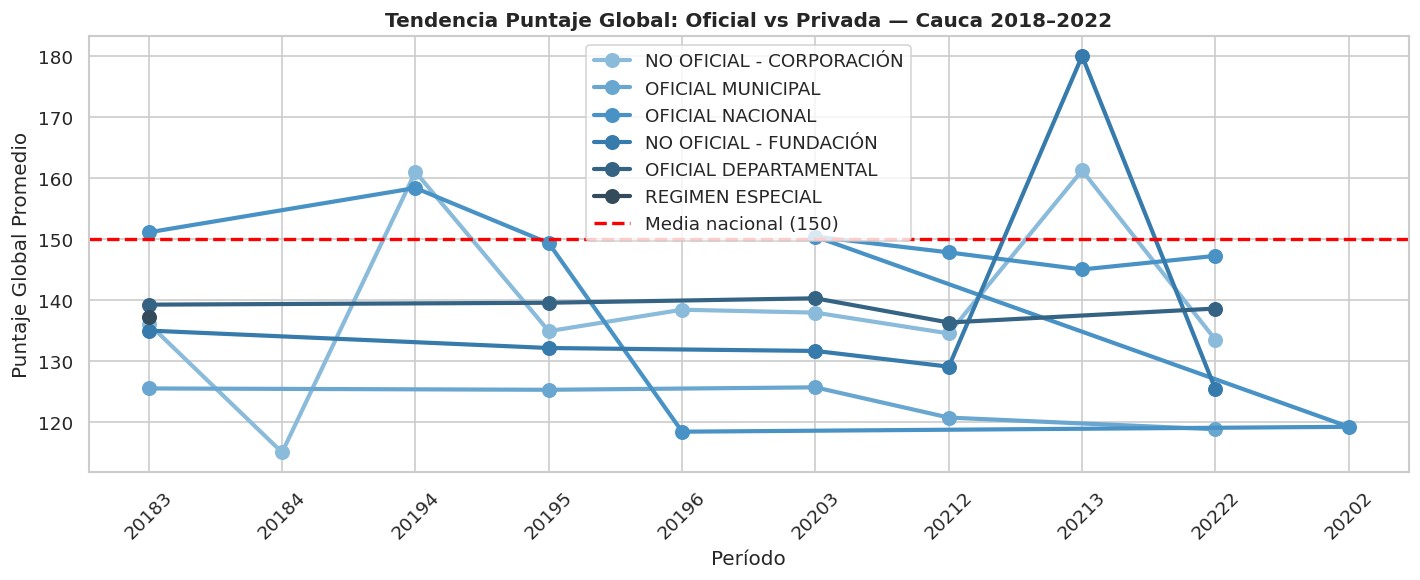

In [39]:
# ─── Tendencia oficial vs privada por período ────────────────────────────────
plt.figure(figsize=(12, 5))

for origen in df_cauca.select('ORIGEN_IES').distinct().collect():
    val = origen['ORIGEN_IES']
    if val:
        tend_origen = df_cauca.filter(F.col('ORIGEN_IES') == val) \
            .groupBy('PERIODO') \
            .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio')) \
            .orderBy('PERIODO').toPandas()
        plt.plot(tend_origen['PERIODO'].astype(str),
                 tend_origen['Promedio'],
                 marker='o', linewidth=2.5, label=val, markersize=8)

plt.axhline(y=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
            label='Media nacional (150)')
plt.title('Tendencia Puntaje Global: Oficial vs Privada — Cauca 2018–2022')
plt.xlabel('Período')
plt.ylabel('Puntaje Global Promedio')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== TOP 5 MUNICIPIOS CON MAYOR PUNTAJE ===
NOMBRE_MUNICIPIO  Promedio  Estudiantes  Brecha vs Nacional  Brecha vs Cauca
         POPAYÁN    143.26        12924                6.74            -3.36
         CAJIBÍO    142.18          123                7.82            -2.28
PIENDAMÓ - TUNÍA    141.59          351                8.41            -1.69
          TIMBÍO    140.00          438               10.00            -0.10
         MIRANDA    139.79          369               10.21             0.11

=== TOP 5 MUNICIPIOS CON MENOR PUNTAJE ===
NOMBRE_MUNICIPIO  Promedio  Estudiantes  Brecha vs Nacional  Brecha vs Cauca
        GUACHENÉ    122.62          244               27.38            17.28
         TORIBÍO    122.57          171               27.43            17.33
           GUAPI    112.74          136               37.26            27.16
  LÓPEZ DE MICAY    109.54           24               40.46            30.36
        TIMBIQUÍ    109.27          103               40.73       

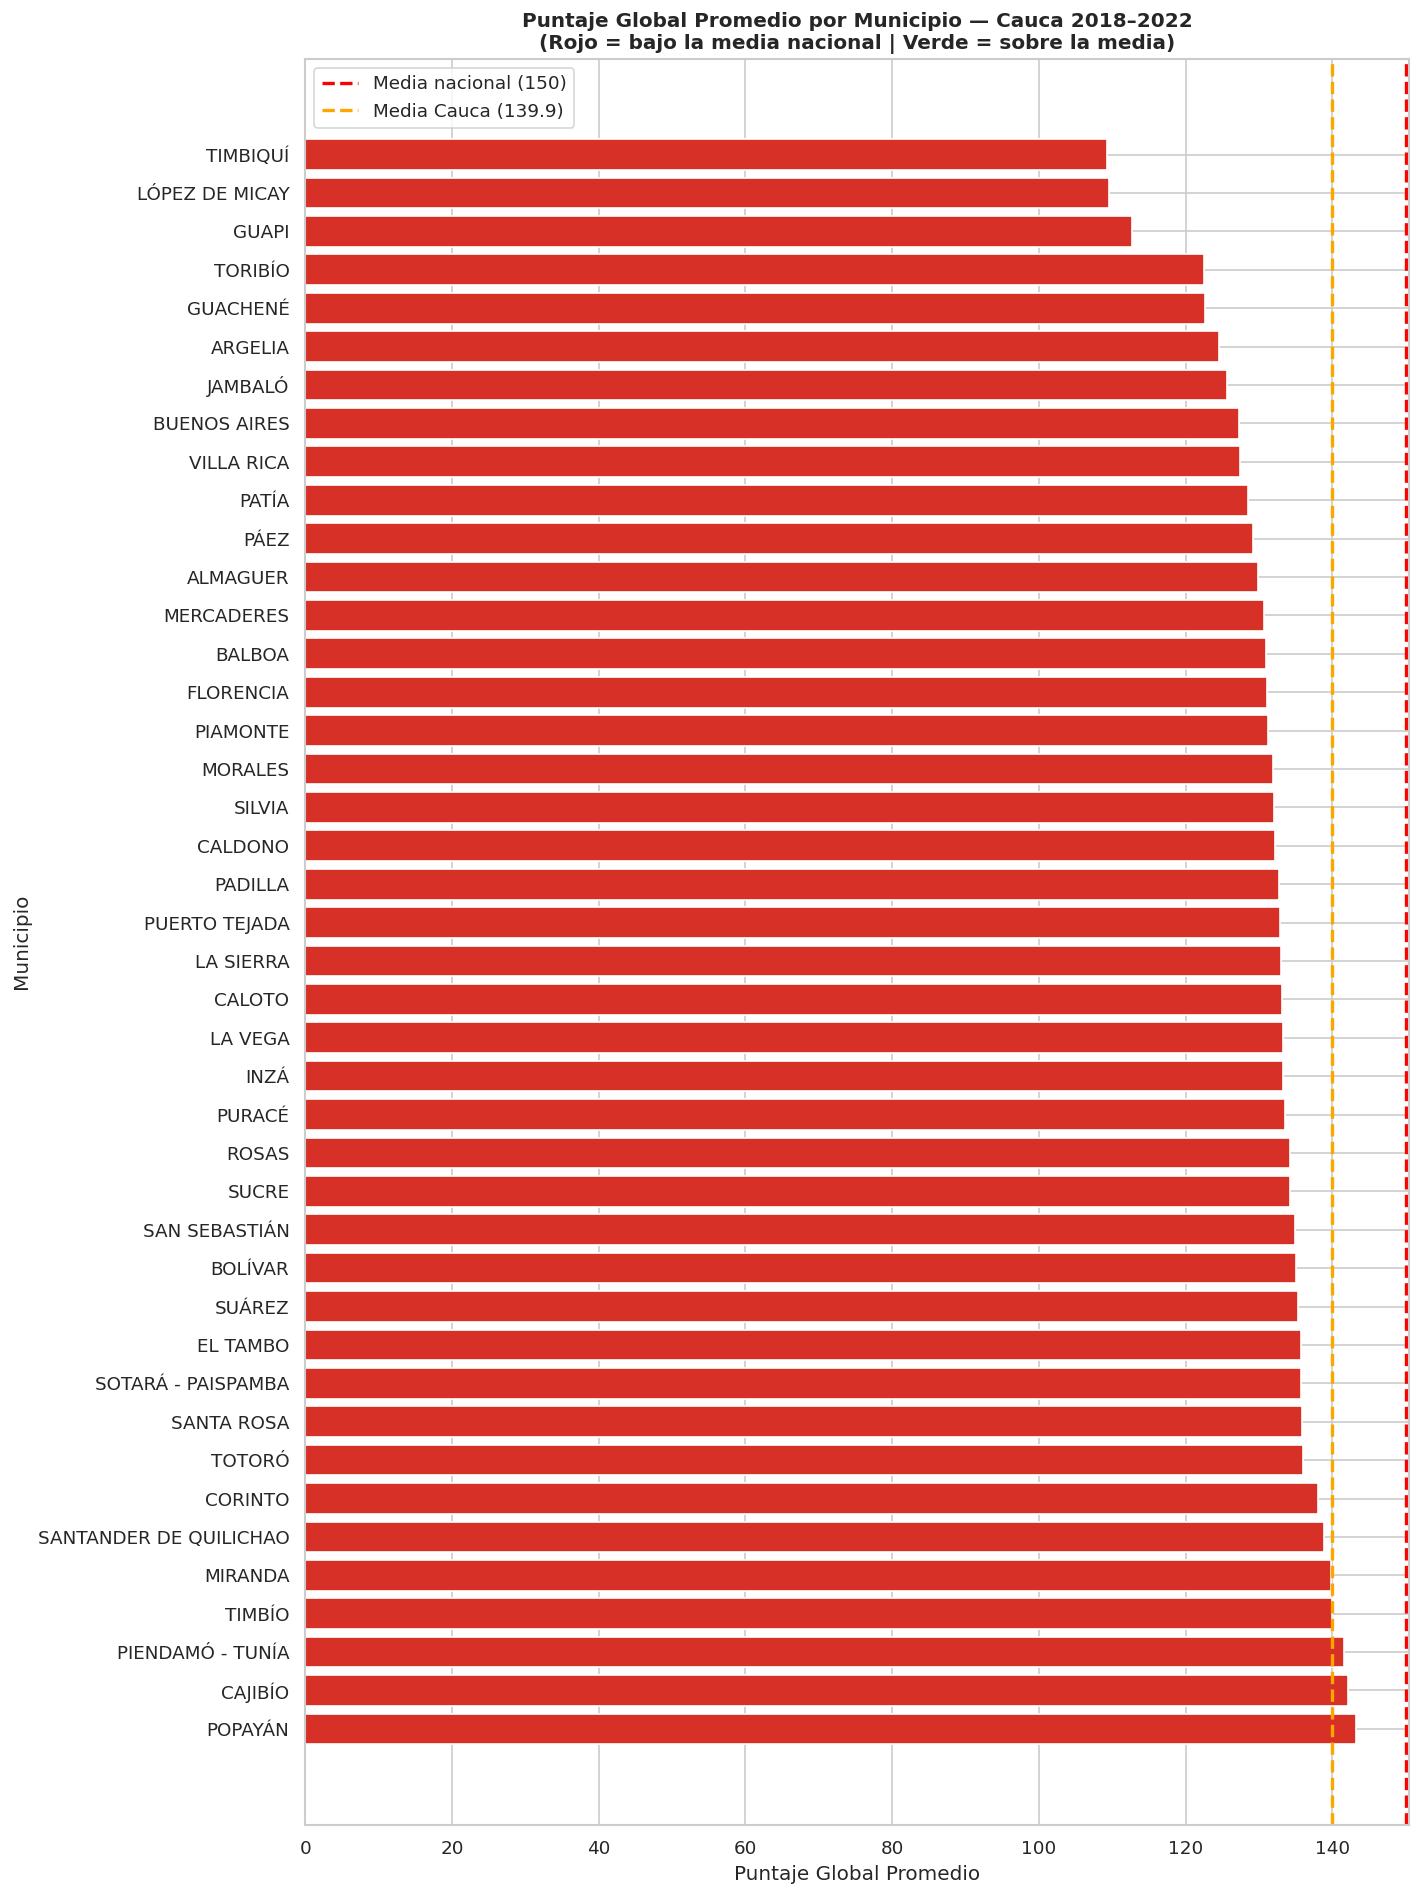

In [40]:
# ─── Puntaje global por municipio ────────────────────────────────────────────
municipio_punt = df_cauca.filter(F.col('NOMBRE_MUNICIPIO').isNotNull()) \
    .groupBy('NOMBRE_MUNICIPIO') \
    .agg(F.round(F.mean('PUNT_GLOBAL'), 2).alias('Promedio'),
         F.count('PUNT_GLOBAL').alias('Estudiantes')) \
    .orderBy(F.desc('Promedio')) \
    .toPandas()

municipio_punt['Brecha vs Nacional'] = (MEDIA_NACIONAL - municipio_punt['Promedio']).round(2)
municipio_punt['Brecha vs Cauca'] = (media_cauca - municipio_punt['Promedio']).round(2)

print("=== TOP 5 MUNICIPIOS CON MAYOR PUNTAJE ===")
print(municipio_punt.head(5).to_string(index=False))
print("\n=== TOP 5 MUNICIPIOS CON MENOR PUNTAJE ===")
print(municipio_punt.tail(5).to_string(index=False))

# Gráfico
altura = max(8, len(municipio_punt) * 0.38)
plt.figure(figsize=(12, altura))
colores_m = ['#1a9850' if v >= MEDIA_NACIONAL else '#d73027'
             for v in municipio_punt['Promedio']]
plt.barh(municipio_punt['NOMBRE_MUNICIPIO'],
         municipio_punt['Promedio'],
         color=colores_m, edgecolor='white')
plt.axvline(x=MEDIA_NACIONAL, color='red', linestyle='--', linewidth=2,
            label=f'Media nacional ({MEDIA_NACIONAL:.0f})')
plt.axvline(x=media_cauca, color='orange', linestyle='--', linewidth=2,
            label=f'Media Cauca ({media_cauca:.1f})')
plt.title('Puntaje Global Promedio por Municipio — Cauca 2018–2022\n'
          '(Rojo = bajo la media nacional | Verde = sobre la media)')
plt.xlabel('Puntaje Global Promedio')
plt.ylabel('Municipio')
plt.legend()
plt.tight_layout()
plt.show()

---
## 2.10 Identificación y síntesis de brechas de desempeño académico

### Objetivo (OE1 + OE2 + OE3)
Esta sección sintetiza todos los hallazgos del EDA para identificar,
cuantificar y jerarquizar las brechas de desempeño académico del Cauca.
Responde directamente a los tres objetivos específicos del proyecto.

### ¿Qué es una brecha en este contexto?
La diferencia en puntos entre el promedio de un grupo (estrato, municipio, tipo IES)
y la media nacional de referencia (150 puntos). Una brecha positiva indica
rendimiento inferior al promedio nacional.

In [41]:
# ─── Brecha global Cauca vs Nacional ─────────────────────────────────────────
print("=== SÍNTESIS DE BRECHAS — CAUCA 2018–2022 ===")

# Por competencia
promedios_row = df_cauca.select(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)],
    F.round(F.mean('PUNT_GLOBAL'), 2).alias('Global')
).collect()[0]

brechas_comp = pd.DataFrame({
    'Competencia':    NOMBRES_PUNTAJES + ['Global'],
    'Promedio Cauca': [promedios_row[n] for n in NOMBRES_PUNTAJES + ['Global']],
    'Media Nacional': MEDIA_NACIONAL
})
brechas_comp['Brecha']   = (MEDIA_NACIONAL - brechas_comp['Promedio Cauca']).round(2)
brechas_comp['% Brecha'] = (brechas_comp['Brecha'] / MEDIA_NACIONAL * 100).round(2)
brechas_comp['Prioridad'] = brechas_comp['Brecha'].apply(
    lambda x: '🔴 Alta' if x > 5 else ('🟡 Media' if x > 2 else '🟢 Baja')
)
brechas_comp = brechas_comp.sort_values('Brecha', ascending=False)
print(brechas_comp.to_string(index=False))

=== SÍNTESIS DE BRECHAS — CAUCA 2018–2022 ===
 Competencia  Promedio Cauca  Media Nacional  Brecha  % Brecha Prioridad
   Escritura          137.44           150.0   12.56      8.37    🔴 Alta
  Ciudadanas          138.61           150.0   11.39      7.59    🔴 Alta
      Global          139.90           150.0   10.10      6.73    🔴 Alta
Razonamiento          139.90           150.0   10.10      6.73    🔴 Alta
      Inglés          140.44           150.0    9.56      6.37    🔴 Alta
     Lectura          142.57           150.0    7.43      4.95    🔴 Alta


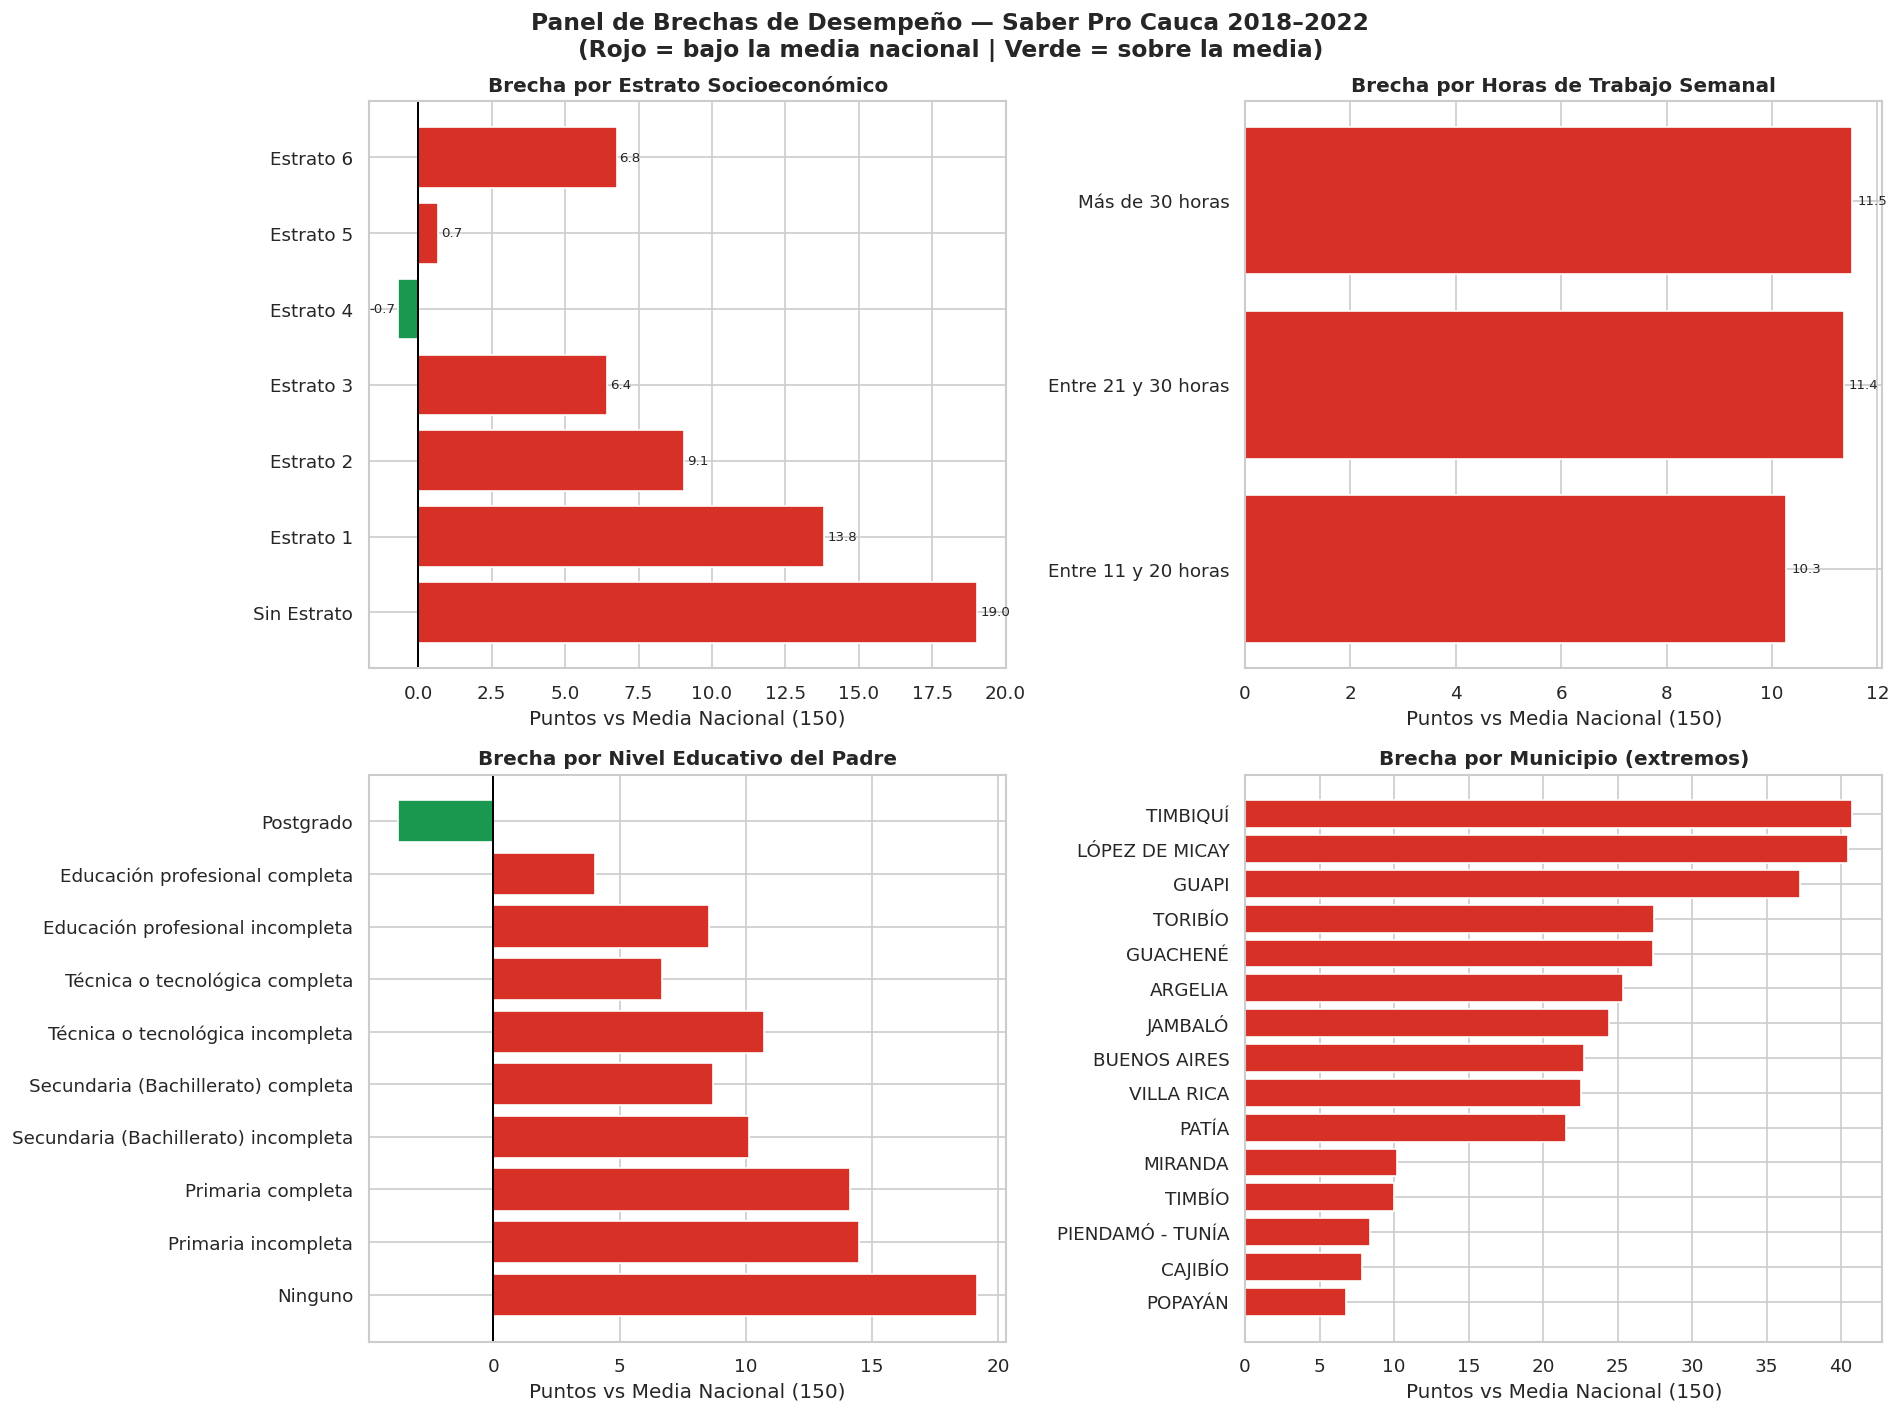

In [42]:
# ─── Panel de brechas por variable ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Brecha por estrato
brecha_est = estrato_punt.copy()
brecha_est['Brecha'] = MEDIA_NACIONAL - brecha_est['Promedio']
colores1 = ['#d73027' if b > 0 else '#1a9850' for b in brecha_est['Brecha']]
axes[0,0].barh(brecha_est.index, brecha_est['Brecha'], color=colores1)
axes[0,0].axvline(x=0, color='black', linewidth=1.2)
for i, (idx, row) in enumerate(brecha_est.iterrows()):
    axes[0,0].text(row['Brecha'] + 0.1 if row['Brecha'] >= 0 else row['Brecha'] - 0.1,
                   i, f"{row['Brecha']:.1f}", va='center', fontsize=8,
                   ha='left' if row['Brecha'] >= 0 else 'right')
axes[0,0].set_title('Brecha por Estrato Socioeconómico', fontweight='bold')
axes[0,0].set_xlabel('Puntos vs Media Nacional (150)')

# 2. Brecha por horas de trabajo
brecha_hor = horas_punt.copy()
brecha_hor['Brecha'] = MEDIA_NACIONAL - brecha_hor['Promedio']
colores2 = ['#d73027' if b > 0 else '#1a9850' for b in brecha_hor['Brecha']]
axes[0,1].barh(brecha_hor.index, brecha_hor['Brecha'], color=colores2)
axes[0,1].axvline(x=0, color='black', linewidth=1.2)
for i, (idx, row) in enumerate(brecha_hor.iterrows()):
    axes[0,1].text(row['Brecha'] + 0.1 if row['Brecha'] >= 0 else row['Brecha'] - 0.1,
                   i, f"{row['Brecha']:.1f}", va='center', fontsize=8,
                   ha='left' if row['Brecha'] >= 0 else 'right')
axes[0,1].set_title('Brecha por Horas de Trabajo Semanal', fontweight='bold')
axes[0,1].set_xlabel('Puntos vs Media Nacional (150)')

# 3. Brecha por educación del padre
brecha_pad = padre_punt.copy()
brecha_pad['Brecha'] = MEDIA_NACIONAL - brecha_pad['Promedio']
colores3 = ['#d73027' if b > 0 else '#1a9850' for b in brecha_pad['Brecha']]
axes[1,0].barh(brecha_pad.index, brecha_pad['Brecha'], color=colores3)
axes[1,0].axvline(x=0, color='black', linewidth=1.2)
axes[1,0].set_title('Brecha por Nivel Educativo del Padre', fontweight='bold')
axes[1,0].set_xlabel('Puntos vs Media Nacional (150)')

# 4. Brecha por municipio (top 15 más extremos)
mpio_extremos = pd.concat([
    municipio_punt.head(5),
    municipio_punt.tail(10)
]).drop_duplicates()
colores4 = ['#1a9850' if b <= 0 else '#d73027' for b in mpio_extremos['Brecha vs Nacional']]
axes[1,1].barh(mpio_extremos['NOMBRE_MUNICIPIO'],
               mpio_extremos['Brecha vs Nacional'], color=colores4)
axes[1,1].axvline(x=0, color='black', linewidth=1.2)
axes[1,1].set_title('Brecha por Municipio (extremos)', fontweight='bold')
axes[1,1].set_xlabel('Puntos vs Media Nacional (150)')

plt.suptitle('Panel de Brechas de Desempeño — Saber Pro Cauca 2018–2022\n'
             '(Rojo = bajo la media nacional | Verde = sobre la media)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

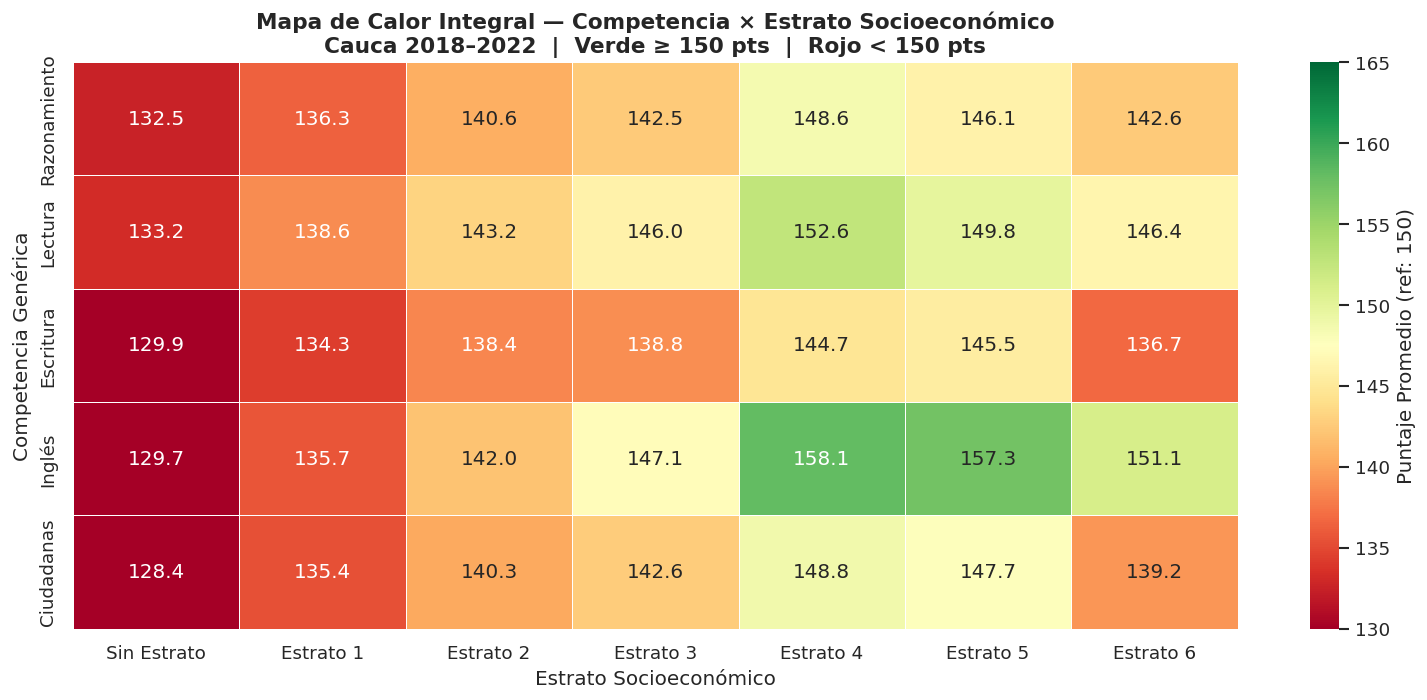

In [43]:
# ─── Heatmap general: estrato x competencia ──────────────────────────────────
# Vista integrada que sintetiza OE1 + OE2

matriz = df_cauca.groupBy('ESTRATO').agg(
    *[F.round(F.mean(p), 2).alias(n) for p, n in zip(PUNTAJES, NOMBRES_PUNTAJES)]
).toPandas().set_index('ESTRATO').reindex(ORDEN_ESTRATO).dropna()

plt.figure(figsize=(13, 6))
sns.heatmap(matriz.T, annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=130, vmax=165,
            linewidths=0.6, linecolor='white',
            cbar_kws={'label': 'Puntaje Promedio (ref: 150)'})
plt.title('Mapa de Calor Integral — Competencia × Estrato Socioeconómico\n'
          'Cauca 2018–2022  |  Verde ≥ 150 pts  |  Rojo < 150 pts',
          fontsize=13)
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Competencia Genérica')
plt.tight_layout()
plt.show()

In [44]:
# ─── RESUMEN EJECUTIVO FINAL ──────────────────────────────────────────────────
media_global = df_cauca.select(F.mean('PUNT_GLOBAL')).collect()[0][0]

print("\n" + "="*65)
print("   RESUMEN EJECUTIVO — BRECHAS SABER PRO CAUCA 2018–2022")
print("="*65)

print(f"\n  📊 BRECHA GLOBAL:")
print(f"     Promedio Cauca:        {media_global:.2f} puntos")
print(f"     Media Nacional:        {MEDIA_NACIONAL:.2f} puntos")
print(f"     Brecha total:          {MEDIA_NACIONAL - media_global:.2f} puntos")
print(f"     % de la media nac.:    {(media_global/MEDIA_NACIONAL*100):.1f}%")

print(f"\n  📚 COMPETENCIA CON MAYOR BRECHA:")
mayor = brechas_comp[brechas_comp['Competencia'] != 'Global'].iloc[0]
print(f"     {mayor['Competencia']}: {mayor['Brecha']} puntos ({mayor['% Brecha']}% de la media)")

print(f"\n  📚 COMPETENCIA CON MENOR BRECHA:")
menor = brechas_comp[brechas_comp['Competencia'] != 'Global'].iloc[-1]
print(f"     {menor['Competencia']}: {menor['Brecha']} puntos ({menor['% Brecha']}% de la media)")

if not brecha_est.empty:
    idx = brecha_est['Brecha'].idxmax()
    print(f"\n  💰 ESTRATO CON MAYOR BRECHA:")
    print(f"     {idx}: {brecha_est.loc[idx,'Brecha']:.2f} puntos bajo la media")

if not brecha_hor.empty:
    idx = brecha_hor['Brecha'].idxmax()
    print(f"\n  ⏰ CONDICIÓN LABORAL CON MAYOR BRECHA:")
    print(f"     {idx}: {brecha_hor.loc[idx,'Brecha']:.2f} puntos bajo la media")

origen_punt_idx = origen_punt.set_index('ORIGEN_IES')
if not origen_punt_idx.empty:
    idx = origen_punt_idx['Brecha vs Nacional'].idxmax()
    print(f"\n  🏛️  TIPO DE IES CON MAYOR BRECHA:")
    print(f"     {idx}: {origen_punt_idx.loc[idx,'Brecha vs Nacional']:.2f} puntos")

if not municipio_punt.empty:
    mpio_min = municipio_punt.iloc[-1]
    print(f"\n  📍 MUNICIPIO CON MAYOR BRECHA:")
    print(f"     {mpio_min['NOMBRE_MUNICIPIO']}: "
          f"{mpio_min['Brecha vs Nacional']:.2f} puntos bajo la media")

print("\n  ✅ FASES CRISP-DM COMPLETADAS:")
print("     Fase 3: Preparación de datos  ✅")
print("     Fase 4: Análisis (EDA)         ✅")
print("="*65)
print("  🚀 Siguiente paso: Capítulo 3 — Dashboard en Power BI")
print("="*65)


   RESUMEN EJECUTIVO — BRECHAS SABER PRO CAUCA 2018–2022

  📊 BRECHA GLOBAL:
     Promedio Cauca:        139.90 puntos
     Media Nacional:        150.00 puntos
     Brecha total:          10.10 puntos
     % de la media nac.:    93.3%

  📚 COMPETENCIA CON MAYOR BRECHA:
     Escritura: 12.56 puntos (8.37% de la media)

  📚 COMPETENCIA CON MENOR BRECHA:
     Lectura: 7.43 puntos (4.95% de la media)

  💰 ESTRATO CON MAYOR BRECHA:
     Sin Estrato: 19.04 puntos bajo la media

  ⏰ CONDICIÓN LABORAL CON MAYOR BRECHA:
     Más de 30 horas: 11.52 puntos bajo la media

  🏛️  TIPO DE IES CON MAYOR BRECHA:
     OFICIAL MUNICIPAL: 26.31 puntos

  📍 MUNICIPIO CON MAYOR BRECHA:
     TIMBIQUÍ: 40.73 puntos bajo la media

  ✅ FASES CRISP-DM COMPLETADAS:
     Fase 3: Preparación de datos  ✅
     Fase 4: Análisis (EDA)         ✅
  🚀 Siguiente paso: Capítulo 3 — Dashboard en Power BI


---
## 💾 Exportar dataset para Power BI

Exportamos el dataset enriquecido (con PUNT_GLOBAL y NOMBRE_MUNICIPIO)
en formato CSV para importarlo directamente en Power BI Desktop.

In [45]:
# ─── Exportar CSV para Power BI ──────────────────────────────────────────────
print("⏳ Exportando dataset para Power BI...")
print("   (puede tardar 2-3 minutos para convertir a pandas)")

df_export = df_cauca.toPandas()
df_export.to_csv(RUTA_POWERBI, index=False, encoding='utf-8-sig')

print(f"\n✅ Dataset exportado correctamente")
print(f"   Archivo: cauca_powerbi.csv")
print(f"   Ruta:    {RUTA_POWERBI}")
print(f"   Registros: {len(df_export):,}")
print(f"   Columnas:  {len(df_export.columns)}")
print(f"\n  Columnas disponibles en Power BI:")
for col in df_export.columns:
    print(f"    • {col}")
print("\n📌 En Power BI: Inicio → Obtener datos → Texto/CSV → seleccionar cauca_powerbi.csv")
del df_export

⏳ Exportando dataset para Power BI...
   (puede tardar 2-3 minutos para convertir a pandas)

✅ Dataset exportado correctamente
   Archivo: cauca_powerbi.csv
   Ruta:    /content/drive/MyDrive/SaberPro/cauca_powerbi.csv
   Registros: 20,598
   Columnas:  17

  Columnas disponibles en Power BI:
    • COD_MUNICIPIO
    • PERIODO
    • DEPARTAMENTO
    • GENERO
    • ESTRATO
    • EDUC_PADRE
    • EDUC_MADRE
    • HORAS_TRABAJO
    • CARACTER_IES
    • ORIGEN_IES
    • PUNT_RAZONAMIENTO
    • PUNT_LECTURA
    • PUNT_ESCRITURA
    • PUNT_INGLES
    • PUNT_CIUDADANAS
    • PUNT_GLOBAL
    • NOMBRE_MUNICIPIO

📌 En Power BI: Inicio → Obtener datos → Texto/CSV → seleccionar cauca_powerbi.csv
